<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>

# 📊 **Regresión Logística (GLM) para Auditores Bancarios**

## 1. FUNDAMENTOS TEÓRICOS

### 1.1 ¿Qué es la Regresión Logística?

La **Regresión Logística** es un modelo estadístico de clasificación supervisada que estima la **probabilidad** de que un evento ocurra (variable dependiente binaria: 0/1). A diferencia de la regresión lineal, la salida siempre está acotada entre 0 y 1.


### 1.2 Función Sigmoide (Logística)

$$P(Y=1|X) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

donde: $z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_n X_n$


### 1.3 Log-Odds (Logit)

$$\text{logit}(p) = \log\left(\frac{p}{1-p}\right) = z$$

**Interpretación bancaria:** Si $\beta_1 = 0.5$ para la variable 'días de mora', un aumento de 1 día en mora multiplica las odds de default por $e^{0.5} \approx 1.65$


### 1.4 Aplicaciones en Auditoría Bancaria

| Caso de Uso | Variable Objetivo | Descripción |
|------------|-------------------|-------------|
| **Riesgo de Crédito** | Default (0/1) | ¿El cliente incumplirá su crédito? |
| **Detección de Fraude** | Fraude (0/1) | ¿La transacción es fraudulenta? |
| **Churn Bancario** | Abandono (0/1) | ¿El cliente cerrará su cuenta? |
| **Blanqueo de Capitales** | Sospechoso (0/1) | ¿La operación es sospechosa? |
| **Morosidad** | Mora (0/1) | ¿El crédito entrará en mora? |


### 1.5 Supuestos del Modelo

⚠️ **IMPORTANTE:**
1. **No linealidad:** La relación entre X e Y no tiene que ser lineal (sí entre X y el logit)
2. **No multicolinealidad:** Las variables independientes no deben estar altamente correlacionadas
3. **Independencia de observaciones:** Cada cliente/transacción es independiente
4. **Tamaño muestral:** Se recomienda mínimo 10 eventos por variable predictora
5. **No outliers extremos:** Los valores extremos pueden distorsionar el modelo


### 1.6 Ventajas y Desventajas

| ✅ Ventajas | ❌ Desventajas |
|------------|---------------|
| Altamente interpretable | Asume relación lineal en el logit |
| Produce probabilidades | Sensible a outliers |
| Regulatorialmente aceptado (Basilea) | No captura relaciones complejas |
| Rápido de entrenar | Requiere feature engineering |
| Coeficientes auditables | Puede tener problemas con clases desbalanceadas |

### 1.7 Métricas de Evaluación Clave

- **AUC-ROC:** Capacidad discriminante del modelo (0.5 = aleatorio, 1.0 = perfecto)
- **Kolmogorov-Smirnov (KS):** Separación máxima entre distribuciones de buenos y malos clientes
- **Gini:** Gini = 2*AUC - 1. Usado ampliamente en banca
- **PSI (Population Stability Index):** Estabilidad del modelo en el tiempo

## 2. CONFIGURACIÓN Y LIBRERÍAS

In [ ]:
# Instalación de librerías necesarias
# !pip install scikit-learn pandas numpy matplotlib seaborn statsmodels imbalanced-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss, log_loss, accuracy_score, recall_score, f1_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

import statsmodels.api as sm

# Estadística
import statsmodels.api as sm
from scipy import stats

# Configuración de visualizaciones
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

# Semilla aleatoria para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Librerías cargadas correctamente")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ Librerías cargadas correctamente
NumPy version: 2.1.3
Pandas version: 2.2.3


## 3. LECTURA DE LOS DATOS

In [3]:
# === 3.1 Carga del dataset de auditoría bancaria ===
# Este notebook se adapta al CSV generado en el script introductorio:
# auditoria_bancaria_desbalanceada.csv

DATA_PATH = "../../data/auditoria_bancaria_desbalanceada.csv"

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    # Ruta alternativa si se ejecuta desde otra carpeta
    df = pd.read_csv("/mnt/data/auditoria_bancaria_desbalanceada.csv")

# Variable objetivo del nuevo dataset
TARGET = "riesgo_auditoria"
ID_COL = "id_operacion"

# Variables categóricas y numéricas detectadas automáticamente
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_modelo = [c for c in num_cols if c not in [TARGET, ID_COL]]

print("✅ Dataset cargado correctamente")
print(f"Dimensiones: {df.shape}")
print(f"Variable objetivo: {TARGET}")
print(f"Variable identificadora: {ID_COL}")
print(f"\nVariables numéricas ({len(num_cols_modelo)}):")
print(num_cols_modelo)
print(f"\nVariables categóricas ({len(cat_cols)}):")
print(cat_cols)

display(df.head())


✅ Dataset cargado correctamente
Dimensiones: (15000, 17)
Variable objetivo: riesgo_auditoria
Variable identificadora: id_operacion

Variables numéricas (10):
['importe_operacion', 'saldo_medio_cliente', 'num_operaciones_30d', 'importe_total_30d', 'antiguedad_cliente_meses', 'score_crediticio', 'ratio_ingresos_deuda', 'num_alertas_previas', 'dias_desde_ultima_revision', 'porcentaje_operaciones_internacionales']

Variables categóricas (5):
['canal_operacion', 'tipo_cliente', 'pais_riesgo', 'producto', 'segmento_riesgo_cliente']


,id_operacion,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,canal_operacion,tipo_cliente,pais_riesgo,producto,segmento_riesgo_cliente,riesgo_auditoria
0,1,233.39,11739.05,17,3085.27,25.0,763.0,0.309,1,31.0,0.003,oficina,particular,bajo,prestamo,medio,0
1,2,829.72,411.47,15,10457.08,80.0,665.0,0.248,1,37.0,0.007,web,particular,bajo,transferencia,medio,0
2,3,176.14,2928.34,23,5525.19,21.0,610.0,0.257,0,269.0,0.439,cajero,particular,alto,tarjeta,medio,1
3,4,2141.27,3579.99,16,2347.29,71.0,776.0,0.211,0,326.0,0.120,web,pyme,bajo,cuenta,alto,0
4,5,1039.73,1938.84,16,9070.86,27.0,626.0,0.278,0,150.0,0.179,app,particular,bajo,cuenta,bajo,0


## 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

El análisis exploratorio es **crítico** para el auditor antes de construir cualquier modelo.

In [4]:
# === 4.1 Estadísticas descriptivas ===
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*70)

columnas_excluir = [c for c in [ID_COL, TARGET] if c in df.columns]
desc = df.drop(columns=columnas_excluir).describe(include=[np.number])
print(desc.round(2))


ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS
       importe_operacion  saldo_medio_cliente  num_operaciones_30d  \
count           15000.00             15000.00             15000.00   
mean             1459.92              9824.27                17.93   
std              2694.71             12503.78                 4.25   
min                 5.00               122.35                 4.00   
25%               333.54              3075.90                15.00   
50%               732.08              5977.36                18.00   
75%              1610.82             11731.49                21.00   
max            143318.97            245519.52                36.00   

       importe_total_30d  antiguedad_cliente_meses  score_crediticio  \
count           15000.00                  15000.00          15000.00   
mean            11404.11                     62.70            680.30   
std             22673.63                     33.83             85.03   
min                 0.00         

In [5]:
# === 4.2 Análisis de valores nulos ===
print("\nANÁLISIS DE VALORES NULOS")
print("="*40)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ No hay valores nulos en el dataset")


ANÁLISIS DE VALORES NULOS
✅ No hay valores nulos en el dataset


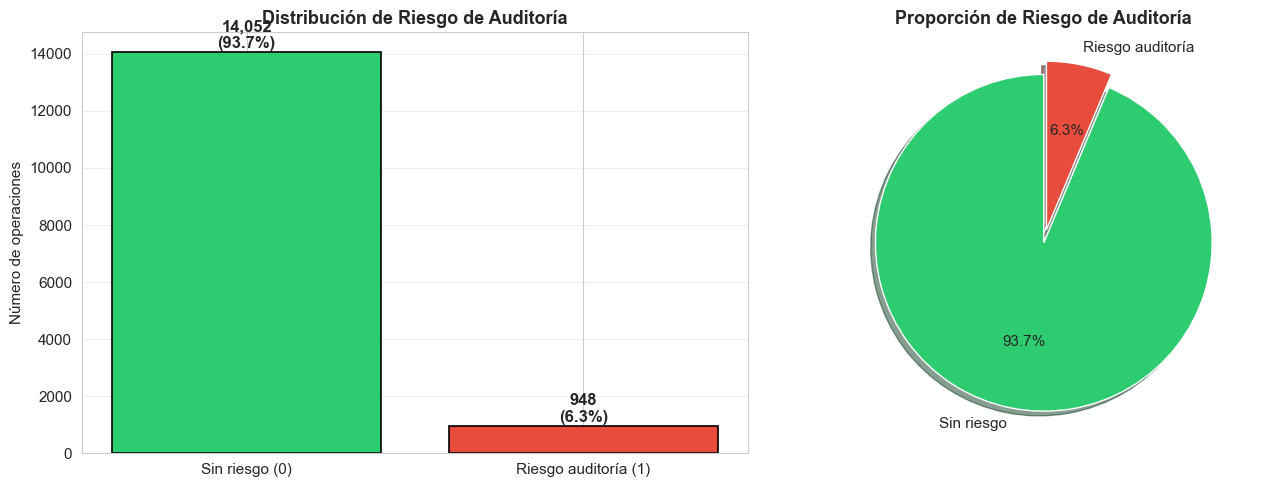

DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
riesgo_auditoria
0    14052
1      948
Name: count, dtype: int64

Tasa de riesgo de auditoría: 6.32%

⚠️ OBSERVACIÓN PARA AUDITORÍA:
Si la clase 1 es minoritaria, accuracy no será suficiente. Hay que priorizar recall, F1, AUC-PR, KS y análisis de umbrales.


In [6]:
# === 4.3 Distribución de la variable objetivo ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colores = ['#2ecc71', '#e74c3c']
conteos = df[TARGET].value_counts().sort_index()

axes[0].bar(['Sin riesgo (0)', 'Riesgo auditoría (1)'], conteos.values, color=colores, edgecolor='black', linewidth=1.2)
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + max(conteos.values)*0.01, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Riesgo de Auditoría', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de operaciones')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(conteos.values, labels=['Sin riesgo', 'Riesgo auditoría'], autopct='%1.1f%%',
            colors=colores, startangle=90, explode=(0, 0.08), shadow=True)
axes[1].set_title('Proporción de Riesgo de Auditoría', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("="*50)
print(conteos)
print(f"\nTasa de riesgo de auditoría: {df[TARGET].mean()*100:.2f}%")
print("\n⚠️ OBSERVACIÓN PARA AUDITORÍA:")
print("Si la clase 1 es minoritaria, accuracy no será suficiente. Hay que priorizar recall, F1, AUC-PR, KS y análisis de umbrales.")


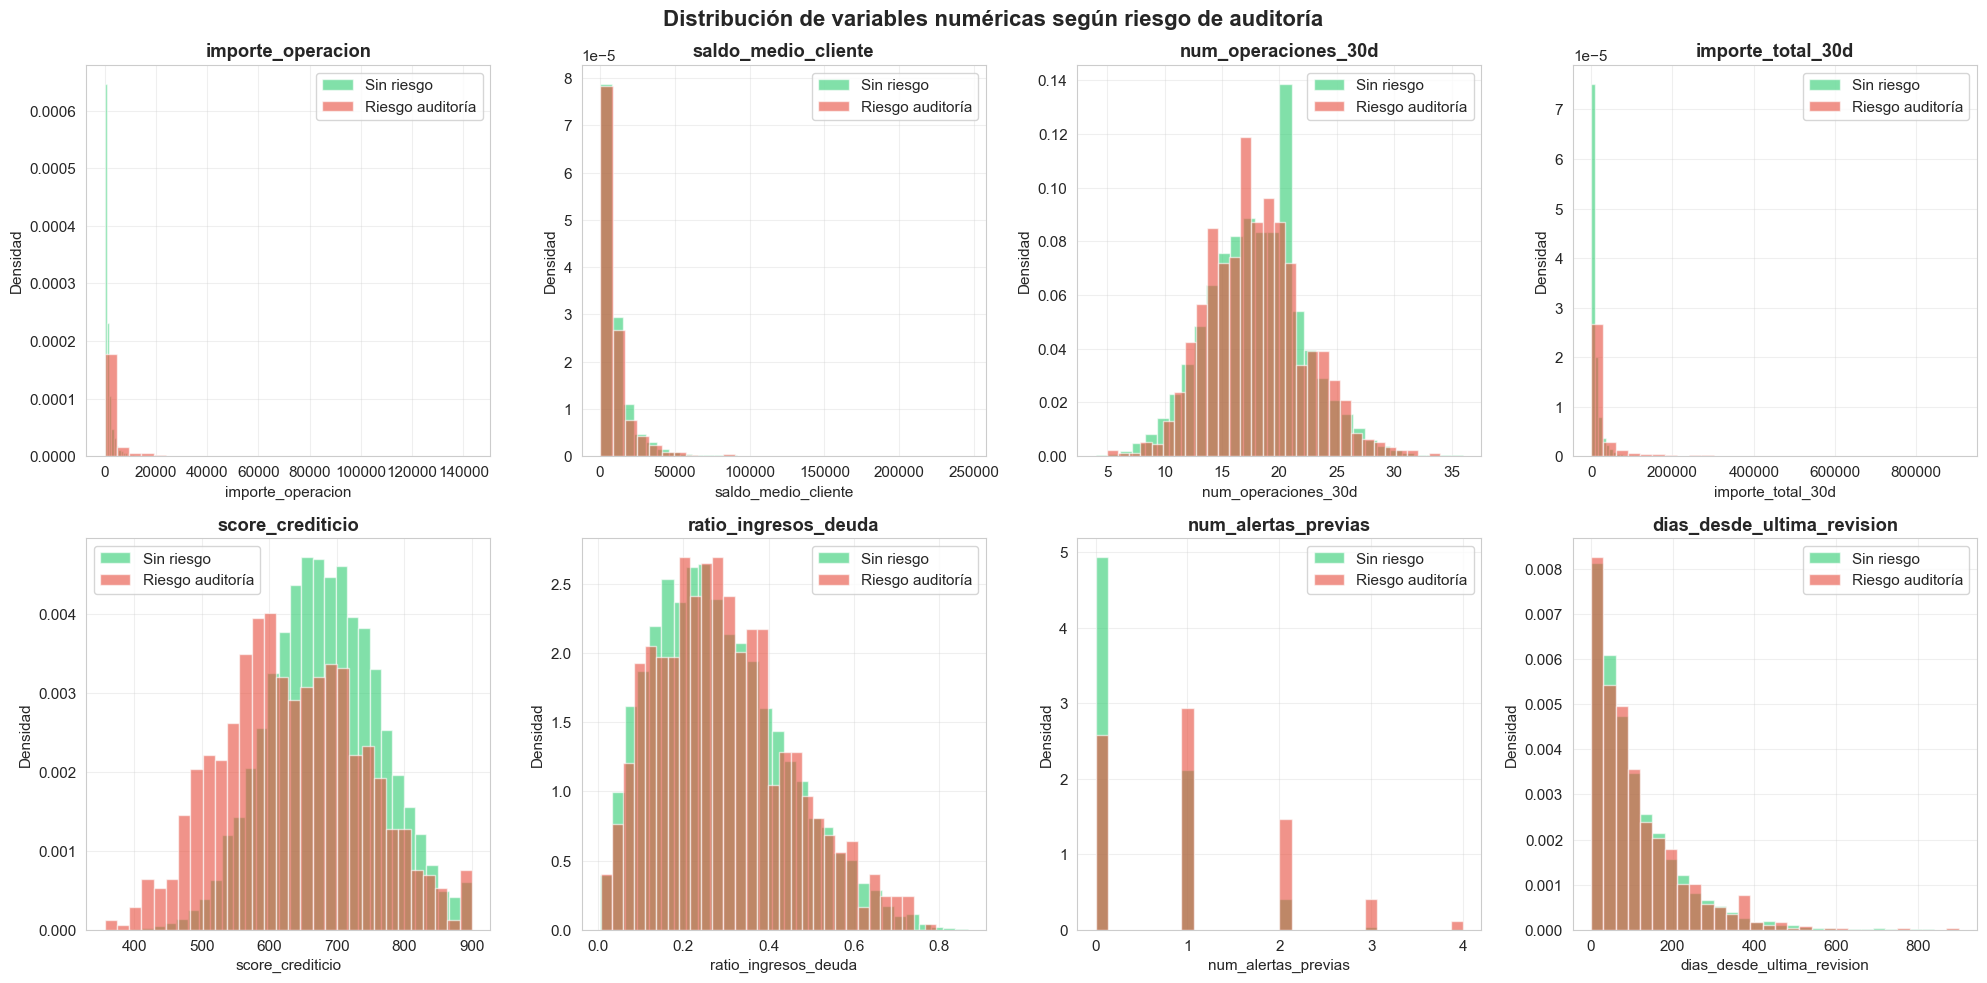

                            Media sin riesgo  Media riesgo auditoría  \
importe_operacion                    1343.55                 3184.96   
saldo_medio_cliente                  9821.31                 9868.19   
num_operaciones_30d                    17.93                   17.96   
importe_total_30d                   10329.14                27338.20   
score_crediticio                      683.40                  634.35   
ratio_ingresos_deuda                    0.29                    0.29   
num_alertas_previas                     0.41                    1.00   
dias_desde_ultima_revision            107.71                  110.57   

                            Diferencia_%  
importe_operacion                 137.06  
saldo_medio_cliente                 0.48  
num_operaciones_30d                 0.15  
importe_total_30d                 164.67  
score_crediticio                   -7.18  
ratio_ingresos_deuda                3.29  
num_alertas_previas               146.57  
dias_de

In [7]:
# === 4.4 Análisis univariado: Variables numéricas vs Riesgo de auditoría ===
vars_numericas = [
    'importe_operacion',
    'saldo_medio_cliente',
    'num_operaciones_30d',
    'importe_total_30d',
    'score_crediticio',
    'ratio_ingresos_deuda',
    'num_alertas_previas',
    'dias_desde_ultima_revision'
]
vars_numericas = [v for v in vars_numericas if v in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, var in enumerate(vars_numericas):
    data_0 = df[df[TARGET] == 0][var]
    data_1 = df[df[TARGET] == 1][var]

    axes[i].hist(data_0, bins=30, alpha=0.6, color='#2ecc71', label='Sin riesgo', density=True)
    axes[i].hist(data_1, bins=30, alpha=0.6, color='#e74c3c', label='Riesgo auditoría', density=True)
    axes[i].set_title(f'{var}', fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Densidad')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

for j in range(len(vars_numericas), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribución de variables numéricas según riesgo de auditoría', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparativa de medias
comparativa = df.groupby(TARGET)[vars_numericas].mean().T
comparativa.columns = ['Media sin riesgo', 'Media riesgo auditoría']
comparativa['Diferencia_%'] = ((comparativa['Media riesgo auditoría'] / comparativa['Media sin riesgo']) - 1) * 100
print(comparativa.round(2))


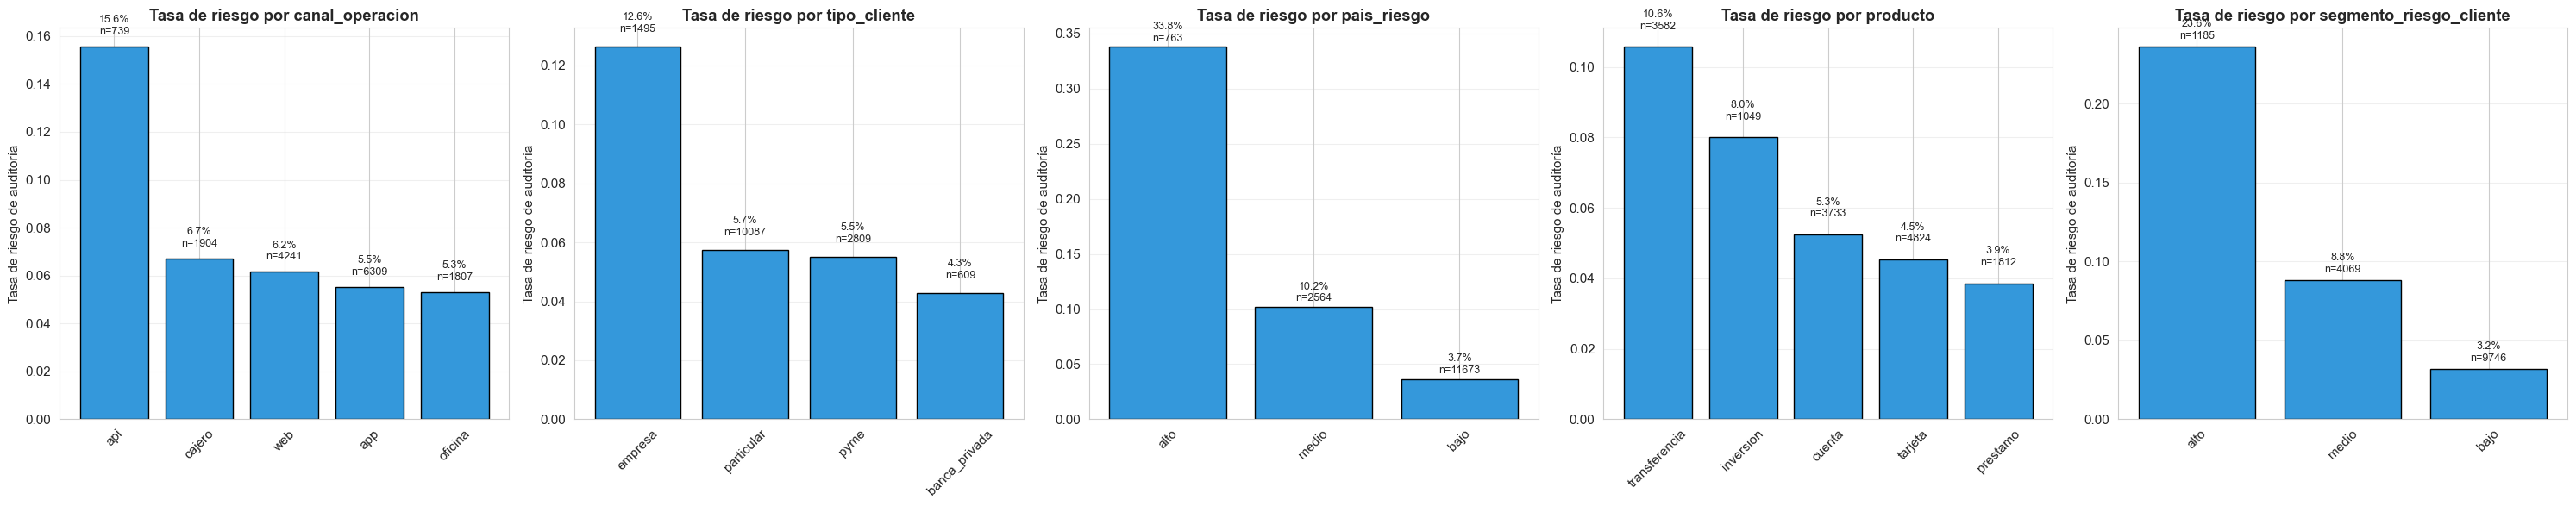

In [8]:
# === 4.5 Variables categóricas vs Riesgo de auditoría ===
vars_categoricas_eda = [c for c in ['canal_operacion', 'tipo_cliente', 'pais_riesgo', 'producto', 'segmento_riesgo_cliente'] if c in df.columns]

n_plots = len(vars_categoricas_eda)
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 6))
if n_plots == 1:
    axes = [axes]

for ax, var in zip(axes, vars_categoricas_eda):
    tasa = df.groupby(var)[TARGET].agg(['mean', 'count']).reset_index()
    tasa.columns = [var, 'tasa_riesgo', 'n_operaciones']
    tasa = tasa.sort_values('tasa_riesgo', ascending=False)

    bars = ax.bar(tasa[var].astype(str), tasa['tasa_riesgo'], color='#3498db', edgecolor='black')
    for bar, count in zip(bars, tasa['n_operaciones']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.1%}\nn={count}', ha='center', fontsize=9)

    ax.set_title(f'Tasa de riesgo por {var}', fontweight='bold')
    ax.set_ylabel('Tasa de riesgo de auditoría')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


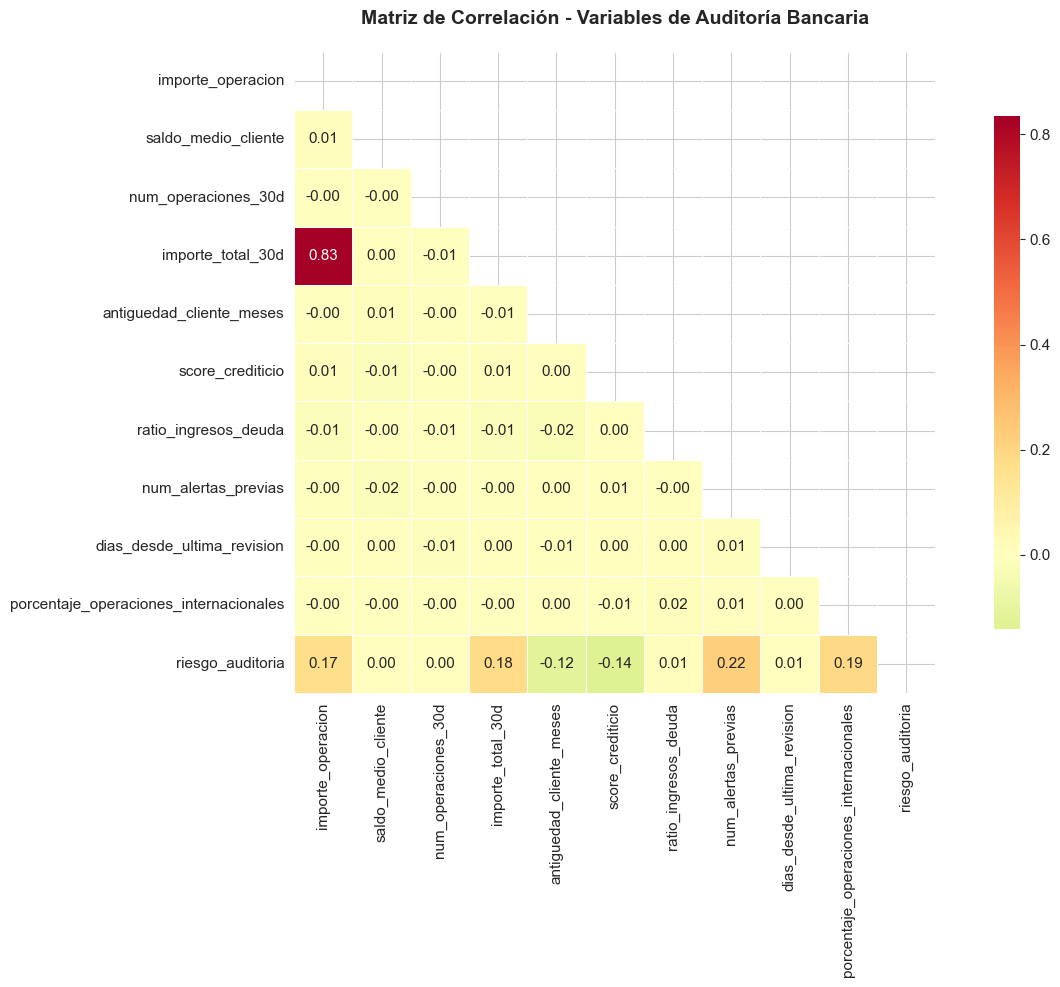

Correlación con la variable objetivo:
riesgo_auditoria                          1.000
num_alertas_previas                       0.220
porcentaje_operaciones_internacionales    0.189
importe_total_30d                         0.183
importe_operacion                         0.166
ratio_ingresos_deuda                      0.015
dias_desde_ultima_revision                0.006
num_operaciones_30d                       0.002
saldo_medio_cliente                       0.001
antiguedad_cliente_meses                 -0.117
score_crediticio                         -0.140
Name: riesgo_auditoria, dtype: float64


In [9]:
# === 4.6 Matriz de correlación ===
vars_corr = num_cols_modelo + [TARGET]
vars_corr = [v for v in vars_corr if v in df.columns]

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlGn_r', center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matriz de Correlación - Variables de Auditoría Bancaria', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Correlación con la variable objetivo:")
print(corr_matrix[TARGET].sort_values(ascending=False).round(3))


## 5. PREPARACIÓN DE DATOS

In [10]:
# === 5.1 Encoding de variables categóricas ===
# Usar get_dummies (one-hot encoding) para variables nominales

columnas_excluir = [c for c in [ID_COL] if c in df.columns]
df_modelo = df.drop(columns=columnas_excluir).copy()

# One-hot encoding de todas las variables categóricas del CSV nuevo
df_modelo = pd.get_dummies(df_modelo, columns=cat_cols, drop_first=True, dtype=int)

print("Variables del modelo después de encoding:")
print(df_modelo.columns.tolist())
print(f"\nDimensiones: {df_modelo.shape}")


Variables del modelo después de encoding:
['importe_operacion', 'saldo_medio_cliente', 'num_operaciones_30d', 'importe_total_30d', 'antiguedad_cliente_meses', 'score_crediticio', 'ratio_ingresos_deuda', 'num_alertas_previas', 'dias_desde_ultima_revision', 'porcentaje_operaciones_internacionales', 'riesgo_auditoria', 'canal_operacion_app', 'canal_operacion_cajero', 'canal_operacion_oficina', 'canal_operacion_web', 'tipo_cliente_empresa', 'tipo_cliente_particular', 'tipo_cliente_pyme', 'pais_riesgo_bajo', 'pais_riesgo_medio', 'producto_inversion', 'producto_prestamo', 'producto_tarjeta', 'producto_transferencia', 'segmento_riesgo_cliente_bajo', 'segmento_riesgo_cliente_medio']

Dimensiones: (15000, 26)


In [11]:
# === 5.2 División Train/Test ===
X = df_modelo.drop(TARGET, axis=1)
y = df_modelo[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("DIVISIÓN DEL DATASET")
print("="*40)
print(f"Training: {len(X_train):,} operaciones ({len(X_train)/len(X)*100:.0f}%)")
print(f"  - Riesgo auditoría: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Testing:  {len(X_test):,} operaciones ({len(X_test)/len(X)*100:.0f}%)")
print(f"  - Riesgo auditoría: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")
print(f"\nVariables predictoras: {X_train.shape[1]}")


DIVISIÓN DEL DATASET
Training: 12,000 operaciones (80%)
  - Riesgo auditoría: 758 (6.3%)
Testing:  3,000 operaciones (20%)
  - Riesgo auditoría: 190 (6.3%)

Variables predictoras: 25


In [12]:
# === 5.3 Escalado de variables (CRÍTICO para regresión logística) ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit SOLO en train!
X_test_scaled = scaler.transform(X_test)         # transform en test

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("⚠️ IMPORTANTE:")
print("El scaler se entrena SOLO en los datos de training (fit_transform)")
print("En testing solo se aplica la transformación (transform)")
print("Usar fit_transform en test = DATA LEAKAGE")

⚠️ IMPORTANTE:
El scaler se entrena SOLO en los datos de training (fit_transform)
En testing solo se aplica la transformación (transform)
Usar fit_transform en test = DATA LEAKAGE


## 6. CONSTRUCCIÓN DEL MODELO

In [13]:
# === 6.1 Modelo base ===
modelo_lr = LogisticRegression(
    penalty='l2',          # Regularización Ridge (evita overfitting)
    C=1.0,                 # Inverso de regularización (menor C = más regularización)
    class_weight='balanced',  # Ajuste por desbalanceo de clases
    solver='lbfgs',        # Optimizador eficiente para datasets medianos
    max_iter=1000,         # Iteraciones máximas
    random_state=RANDOM_STATE
)

modelo_lr.fit(X_train_scaled, y_train)

print("✅ Modelo entrenado exitosamente")
print(f"\nConvergencia: {modelo_lr.n_iter_[0]} iteraciones")

✅ Modelo entrenado exitosamente

Convergencia: 20 iteraciones


In [14]:
# === 6.2 Análisis de coeficientes (FUNDAMENTAL para auditoría) ===
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': modelo_lr.coef_[0],
    'Odds_Ratio': np.exp(modelo_lr.coef_[0]),
    'Efecto': ['↑ Riesgo' if c > 0 else '↓ Riesgo' for c in modelo_lr.coef_[0]]
}).sort_values('Coeficiente', ascending=False)

print("COEFICIENTES DEL MODELO DE REGRESIÓN LOGÍSTICA")
print("="*70)
print(f"Intercepto: {modelo_lr.intercept_[0]:.4f}")
print()
print(coef_df.to_string(index=False))
print()
print("INTERPRETACIÓN:")
print("- Odds Ratio > 1: La variable AUMENTA el riesgo de auditoría")
print("- Odds Ratio < 1: La variable DISMINUYE el riesgo de auditoría")
print("- Coeficiente: Por cada unidad aumentada (estandarizada), el log-odds cambia en ese valor")

COEFICIENTES DEL MODELO DE REGRESIÓN LOGÍSTICA
Intercepto: -2.8631

                              Variable  Coeficiente  Odds_Ratio   Efecto
                   num_alertas_previas     1.081532    2.949194 ↑ Riesgo
porcentaje_operaciones_internacionales     0.919882    2.508993 ↑ Riesgo
                     importe_total_30d     0.609318    1.839176 ↑ Riesgo
                  tipo_cliente_empresa     0.568177    1.765046 ↑ Riesgo
                producto_transferencia     0.500206    1.649061 ↑ Riesgo
               tipo_cliente_particular     0.231319    1.260261 ↑ Riesgo
                     importe_operacion     0.225121    1.252474 ↑ Riesgo
                    producto_inversion     0.205175    1.227740 ↑ Riesgo
                     tipo_cliente_pyme     0.159543    1.172975 ↑ Riesgo
                   saldo_medio_cliente     0.068221    1.070602 ↑ Riesgo
                  ratio_ingresos_deuda     0.010340    1.010394 ↑ Riesgo
                   num_operaciones_30d    -0.028114    0

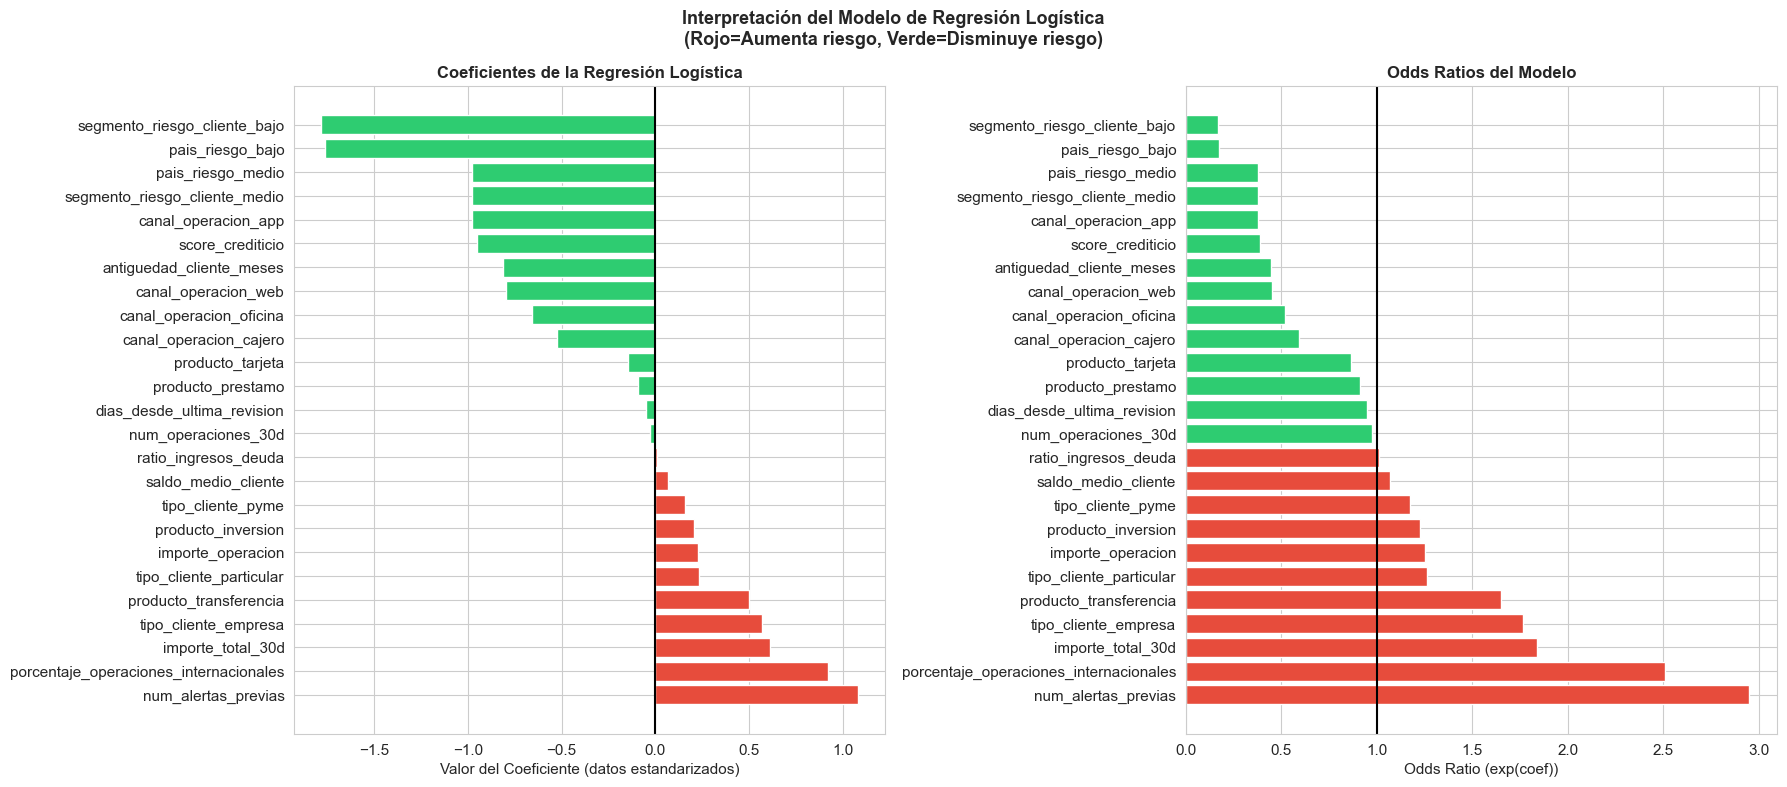

In [15]:
# === 6.3 Visualización de coeficientes ===
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Coeficientes
colores_coef = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coeficiente']]
axes[0].barh(coef_df['Variable'], coef_df['Coeficiente'], color=colores_coef)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1.5)
axes[0].set_title('Coeficientes de la Regresión Logística', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor del Coeficiente (datos estandarizados)')

# Odds Ratios
axes[1].barh(coef_df['Variable'], coef_df['Odds_Ratio'], 
             color=['#e74c3c' if o > 1 else '#2ecc71' for o in coef_df['Odds_Ratio']])
axes[1].axvline(x=1, color='black', linestyle='-', linewidth=1.5)
axes[1].set_title('Odds Ratios del Modelo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Odds Ratio (exp(coef))')

plt.suptitle('Interpretación del Modelo de Regresión Logística\n(Rojo=Aumenta riesgo, Verde=Disminuye riesgo)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. EVALUACIÓN DEL MODELO

### Métricas clave para auditores bancarios

In [16]:
# === 7.1 Predicciones ===
y_pred = modelo_lr.predict(X_test_scaled)
y_prob = modelo_lr.predict_proba(X_test_scaled)[:, 1]

# === 7.2 Métricas de rendimiento ===
print("REPORTE DE CLASIFICACIÓN")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Sin riesgo', 'Riesgo auditoría']))

auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1
brier = brier_score_loss(y_test, y_prob)
ll = log_loss(y_test, y_prob)

print("\nMÉTRICAS ADICIONALES")
print("="*40)
print(f"AUC-ROC:     {auc:.4f}")
print(f"Gini:        {gini:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"Log Loss:    {ll:.4f}")

print("\nINTERPRETACIÓN PARA AUDITORÍA:")
print("- Recall clase 1: capacidad de detectar operaciones con riesgo de auditoría.")
print("- Precision clase 1: proporción de alertas generadas que realmente son riesgo.")
print("- AUC/Gini: capacidad global de ordenar operaciones de menor a mayor riesgo.")
print("- Brier/LogLoss: calidad de las probabilidades, no solo de la clasificación.")


REPORTE DE CLASIFICACIÓN
                  precision    recall  f1-score   support

      Sin riesgo       0.99      0.92      0.95      2810
Riesgo auditoría       0.42      0.92      0.58       190

        accuracy                           0.92      3000
       macro avg       0.71      0.92      0.77      3000
    weighted avg       0.96      0.92      0.93      3000


MÉTRICAS ADICIONALES
AUC-ROC:     0.9511
Gini:        0.9022
Brier Score: 0.0582
Log Loss:    0.1973

INTERPRETACIÓN PARA AUDITORÍA:
- Recall clase 1: capacidad de detectar operaciones con riesgo de auditoría.
- Precision clase 1: proporción de alertas generadas que realmente son riesgo.
- AUC/Gini: capacidad global de ordenar operaciones de menor a mayor riesgo.
- Brier/LogLoss: calidad de las probabilidades, no solo de la clasificación.


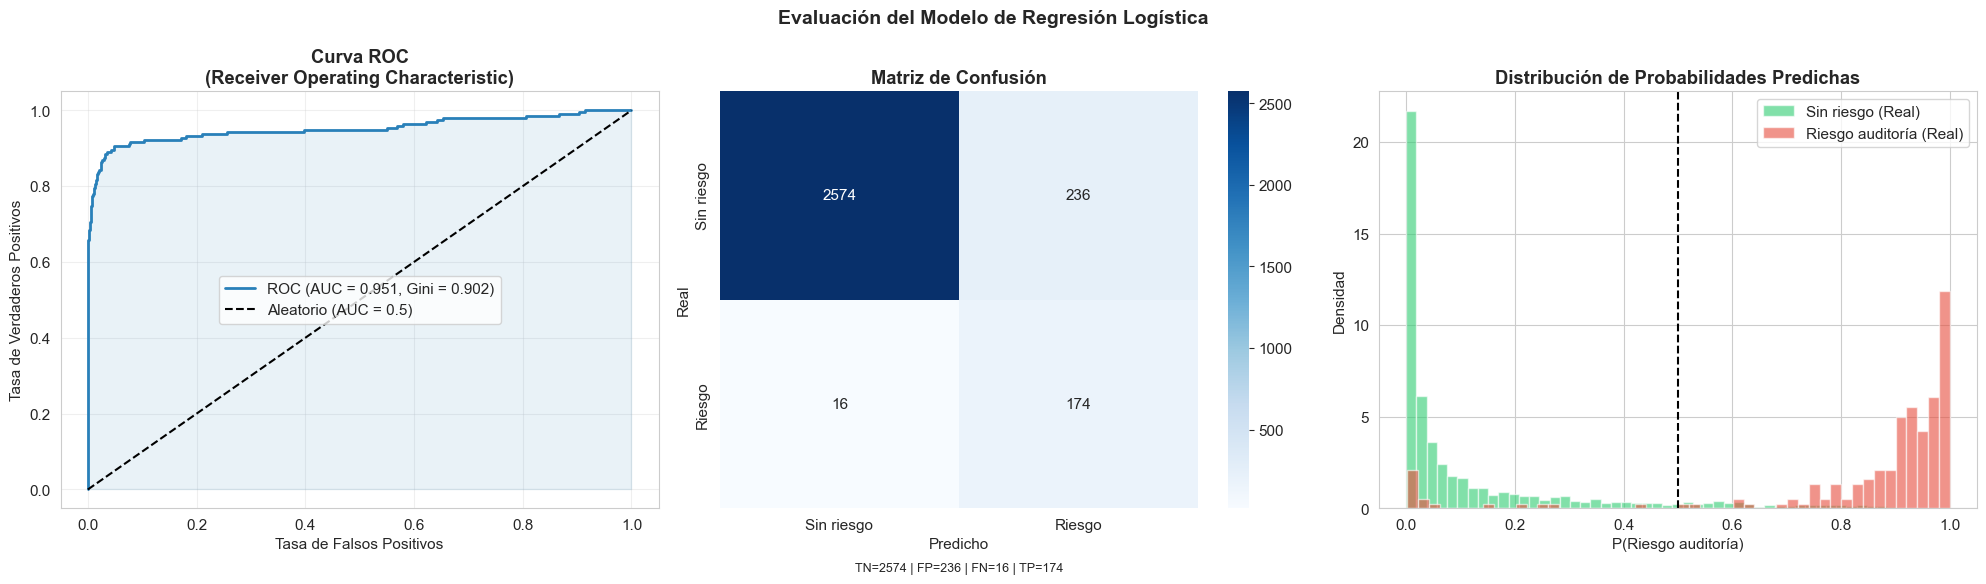


📊 ANÁLISIS DE ERRORES:
Verdaderos Negativos (TN): 2,574 - Correctamente clasificados como 'sin riesgo'
Falsos Positivos (FP):     236 - Clasificados como 'default' pero estaban sin riesgo
Falsos Negativos (FN):     16 - ⚠️ RIESGO: Clasificados 'sin riesgo' pero eran riesgo de auditoría
Verdaderos Positivos (TP): 174 - Correctamente identificados como 'riesgo de auditoría'


In [17]:
# === 7.3 Curva ROC y Matriz de Confusión ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC (AUC = {auc:.3f}, Gini = {gini:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC\n(Receiver Operating Characteristic)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Sin riesgo', 'Riesgo'],
            yticklabels=['Sin riesgo', 'Riesgo'])
axes[1].set_title('Matriz de Confusión', fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

# Añadir métricas sobre la matriz
tn, fp, fn, tp = cm.ravel()
axes[1].text(0.5, -0.15, f'TN={tn} | FP={fp} | FN={fn} | TP={tp}', 
             ha='center', transform=axes[1].transAxes, fontsize=9)

# Distribución de probabilidades predichas
axes[2].hist(y_prob[y_test==0], bins=50, alpha=0.6, color='#2ecc71', label='Sin riesgo (Real)', density=True)
axes[2].hist(y_prob[y_test==1], bins=50, alpha=0.6, color='#e74c3c', label='Riesgo auditoría (Real)', density=True)
axes[2].set_title('Distribución de Probabilidades Predichas', fontweight='bold')
axes[2].set_xlabel('P(Riesgo auditoría)')
axes[2].set_ylabel('Densidad')
axes[2].legend()
axes[2].axvline(x=0.5, color='black', linestyle='--', label='Umbral 0.5')

plt.suptitle('Evaluación del Modelo de Regresión Logística', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 ANÁLISIS DE ERRORES:")
print(f"Verdaderos Negativos (TN): {tn:,} - Correctamente clasificados como 'sin riesgo'")
print(f"Falsos Positivos (FP):     {fp:,} - Clasificados como 'default' pero estaban sin riesgo")
print(f"Falsos Negativos (FN):     {fn:,} - ⚠️ RIESGO: Clasificados 'sin riesgo' pero eran riesgo de auditoría")
print(f"Verdaderos Positivos (TP): {tp:,} - Correctamente identificados como 'riesgo de auditoría'")

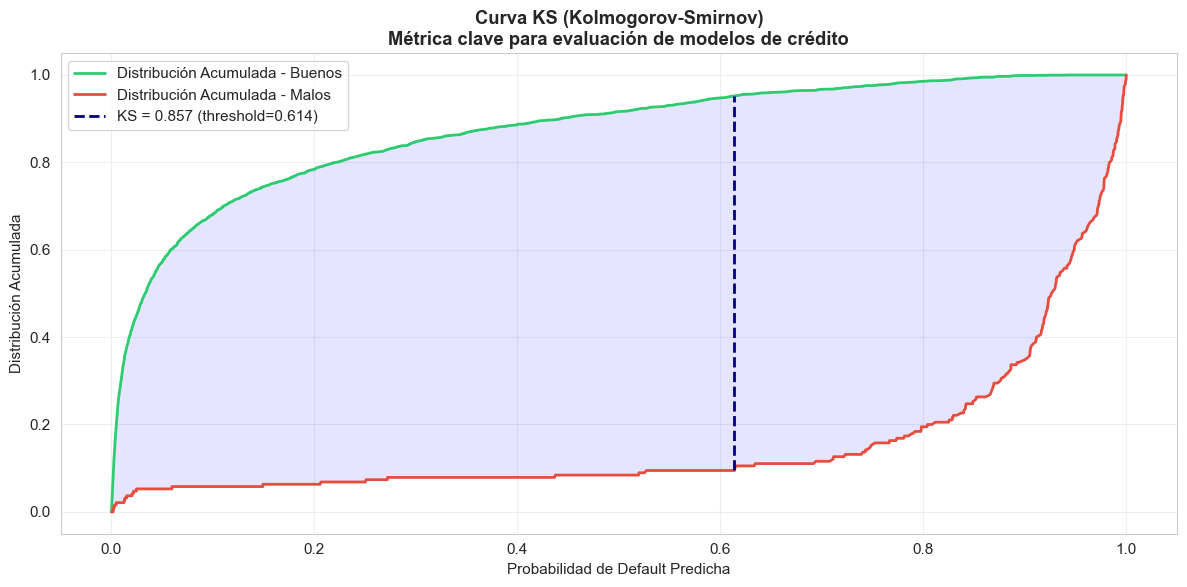


📊 ESTADÍSTICO KS: 0.8572 (85.7%)
Interpretación KS para modelos de crédito:
KS < 0.20: Modelo deficiente
KS 0.20-0.40: Modelo aceptable
KS 0.40-0.60: Modelo bueno
KS > 0.60: Modelo excelente


In [18]:
# === 7.4 Curva KS (Kolmogorov-Smirnov) - MÉTRICA BANCARIA CLAVE ===
# El KS mide la separación máxima entre las distribuciones acumuladas

# Ordenar por probabilidad predicha
ks_df = pd.DataFrame({'prob': y_prob, 'real': y_test.values})
ks_df = ks_df.sort_values('prob')

# Calcular distribuciones acumuladas
total_good = (y_test == 0).sum()
total_bad = (y_test == 1).sum()

ks_df['cum_good'] = (ks_df['real'] == 0).cumsum() / total_good
ks_df['cum_bad'] = (ks_df['real'] == 1).cumsum() / total_bad
ks_df['ks_diff'] = abs(ks_df['cum_good'] - ks_df['cum_bad'])

ks_stat = ks_df['ks_diff'].max()
ks_threshold = ks_df.loc[ks_df['ks_diff'].idxmax(), 'prob']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ks_df['prob'], ks_df['cum_good'], color='#2ecc71', lw=2, label='Distribución Acumulada - Buenos')
ax.plot(ks_df['prob'], ks_df['cum_bad'], color='#e74c3c', lw=2, label='Distribución Acumulada - Malos')

# Marcar el punto KS
ks_good_val = ks_df.loc[ks_df['ks_diff'].idxmax(), 'cum_good']
ks_bad_val = ks_df.loc[ks_df['ks_diff'].idxmax(), 'cum_bad']
ax.vlines(ks_threshold, min(ks_good_val, ks_bad_val), max(ks_good_val, ks_bad_val), 
          colors='navy', linestyles='--', lw=2, label=f'KS = {ks_stat:.3f} (threshold={ks_threshold:.3f})')

ax.fill_between(ks_df['prob'], ks_df['cum_good'], ks_df['cum_bad'], alpha=0.1, color='blue')
ax.set_xlabel('Probabilidad de Default Predicha')
ax.set_ylabel('Distribución Acumulada')
ax.set_title('Curva KS (Kolmogorov-Smirnov)\nMétrica clave para evaluación de modelos de crédito', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 ESTADÍSTICO KS: {ks_stat:.4f} ({ks_stat*100:.1f}%)")
print("Interpretación KS para modelos de crédito:")
print("KS < 0.20: Modelo deficiente")
print("KS 0.20-0.40: Modelo aceptable")
print("KS 0.40-0.60: Modelo bueno")
print("KS > 0.60: Modelo excelente")

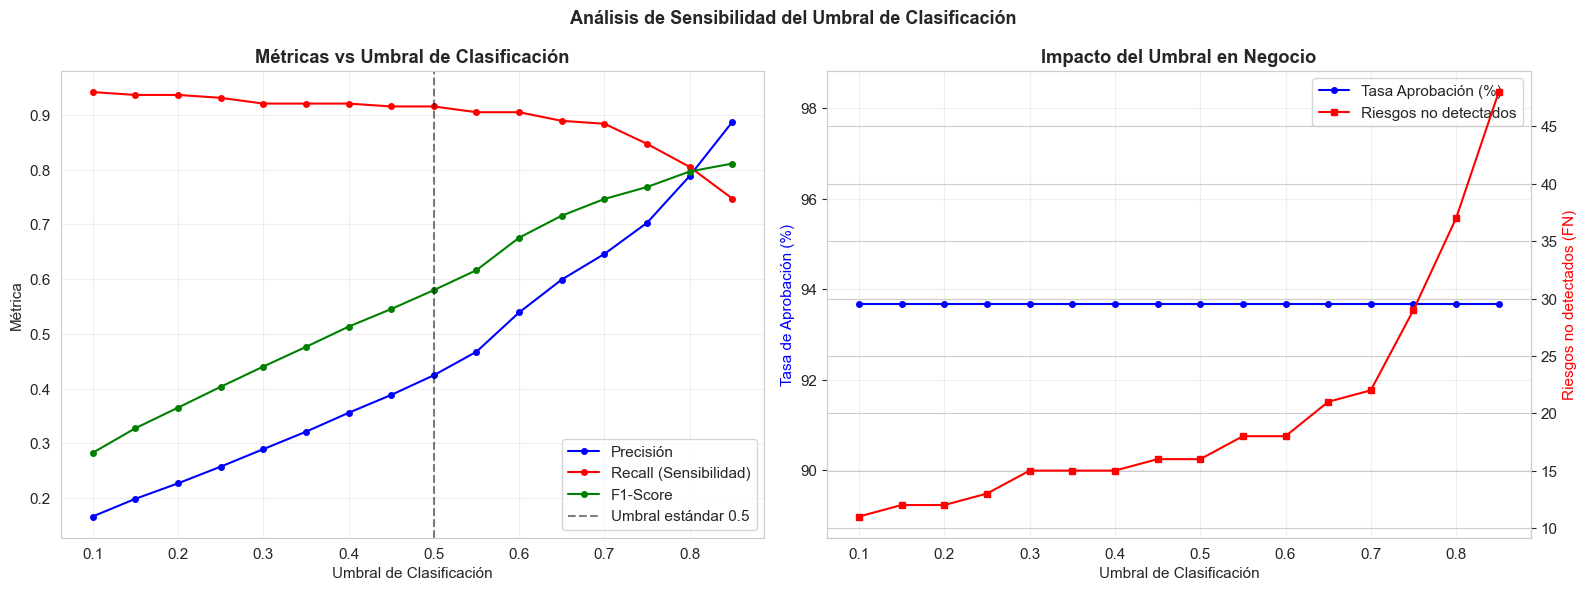


💡 CONSIDERACIÓN BANCARIA:
- Umbral más bajo → Más operaciones derivadas a revisión, menos riesgos no detectados
- Umbral más alto → Menos operaciones revisadas, más riesgos no detectados
- El umbral óptimo depende del costo de FP vs FN en cada banco


In [19]:
# === 7.5 Análisis de umbral óptimo ===
# En banca, la elección del umbral depende del costo del error
thresholds_range = np.arange(0.1, 0.9, 0.05)
metricas_umbral = []

for t in thresholds_range:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    metricas_umbral.append({
        'umbral': t,
        'precision': tp/(tp+fp) if (tp+fp) > 0 else 0,
        'recall': tp/(tp+fn) if (tp+fn) > 0 else 0,
        'f1': 2*tp/(2*tp+fp+fn) if (2*tp+fp+fn) > 0 else 0,
        'tasa_aprobacion': (tn+fp)/len(y_test),
        'riesgos_no_detectados': fn
    })

metricas_df = pd.DataFrame(metricas_umbral)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(metricas_df['umbral'], metricas_df['precision'], 'b-o', label='Precisión', markersize=4)
axes[0].plot(metricas_df['umbral'], metricas_df['recall'], 'r-o', label='Recall (Sensibilidad)', markersize=4)
axes[0].plot(metricas_df['umbral'], metricas_df['f1'], 'g-o', label='F1-Score', markersize=4)
axes[0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Umbral estándar 0.5')
axes[0].set_xlabel('Umbral de Clasificación')
axes[0].set_ylabel('Métrica')
axes[0].set_title('Métricas vs Umbral de Clasificación', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(metricas_df['umbral'], metricas_df['tasa_aprobacion']*100, 'b-o', label='Tasa Aprobación (%)', markersize=4)
ax2_r = ax2.twinx()
ax2_r.plot(metricas_df['umbral'], metricas_df['riesgos_no_detectados'], 'r-s', label='Riesgos no detectados', markersize=4)
ax2.set_xlabel('Umbral de Clasificación')
ax2.set_ylabel('Tasa de Aprobación (%)', color='blue')
ax2_r.set_ylabel('Riesgos no detectados (FN)', color='red')
ax2.set_title('Impacto del Umbral en Negocio', fontweight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2)
ax2.grid(True, alpha=0.3)

plt.suptitle('Análisis de Sensibilidad del Umbral de Clasificación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 CONSIDERACIÓN BANCARIA:")
print("- Umbral más bajo → Más operaciones derivadas a revisión, menos riesgos no detectados")
print("- Umbral más alto → Menos operaciones revisadas, más riesgos no detectados")
print("- El umbral óptimo depende del costo de FP vs FN en cada banco")

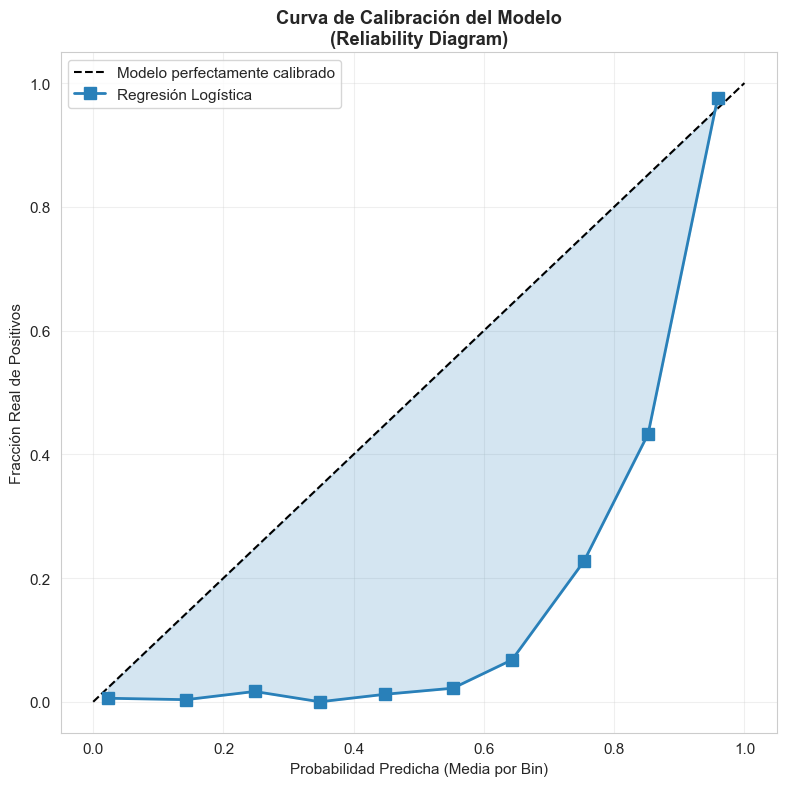

Brier Score: 0.0582
Un modelo bien calibrado sigue la línea diagonal
La Regresión Logística generalmente está bien calibrada


In [20]:
# === 7.6 Calibración del modelo ===
# CRÍTICO: Las probabilidades predichas deben corresponder a probabilidades reales
fig, ax = plt.subplots(figsize=(8, 8))

fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_prob, n_bins=10)

ax.plot([0, 1], [0, 1], 'k--', label='Modelo perfectamente calibrado')
ax.plot(mean_predicted_value, fraction_of_positives, 's-', color='#2980b9', 
        label='Regresión Logística', linewidth=2, markersize=8)
ax.fill_between(mean_predicted_value, fraction_of_positives, mean_predicted_value, 
                alpha=0.2, color='#2980b9')
ax.set_xlabel('Probabilidad Predicha (Media por Bin)')
ax.set_ylabel('Fracción Real de Positivos')
ax.set_title('Curva de Calibración del Modelo\n(Reliability Diagram)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

brier = brier_score_loss(y_test, y_prob)
print(f"Brier Score: {brier:.4f}")
print("Un modelo bien calibrado sigue la línea diagonal")
print("La Regresión Logística generalmente está bien calibrada")

In [21]:
# === 7.7 Validación cruzada ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', 
                               solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE))
])

scores_auc = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
scores_f1 = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')

print("VALIDACIÓN CRUZADA ESTRATIFICADA (5 Folds)")
print("="*50)
print(f"AUC por fold: {scores_auc.round(4)}")
print(f"AUC Medio: {scores_auc.mean():.4f} ± {scores_auc.std():.4f}")
print()
print(f"F1 por fold: {scores_f1.round(4)}")
print(f"F1 Medio: {scores_f1.mean():.4f} ± {scores_f1.std():.4f}")
print()
print(f"⚠️ Coeficiente de Variación AUC: {scores_auc.std()/scores_auc.mean()*100:.1f}%")
if scores_auc.std()/scores_auc.mean() < 0.05:
    print("✅ Modelo estable (CV < 5%)")
else:
    print("⚠️ Modelo con cierta variabilidad (CV > 5%) - Revisar")

VALIDACIÓN CRUZADA ESTRATIFICADA (5 Folds)
AUC por fold: [0.9873 0.9436 0.957  0.9547 0.9605]
AUC Medio: 0.9606 ± 0.0145

F1 por fold: [0.5896 0.5824 0.5932 0.5784 0.571 ]
F1 Medio: 0.5829 ± 0.0079

⚠️ Coeficiente de Variación AUC: 1.5%
✅ Modelo estable (CV < 5%)


## 8. PSI - POPULATION STABILITY INDEX

El PSI es fundamental para el monitoreo continuo del modelo en producción bancaria.

In [22]:
def calcular_psi(expected, actual, n_bins=10):
    """
    Calcula el Population Stability Index (PSI)
    Compara la distribución de scores entre dos períodos
    """
    bins = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    bins[0] = -np.inf
    bins[-1] = np.inf
    
    expected_bins = pd.Series(pd.cut(expected, bins=bins))
    actual_bins = pd.Series(pd.cut(actual, bins=bins))
    
    expected_perc = expected_bins.value_counts(normalize=True).sort_index()
    actual_perc = actual_bins.value_counts(normalize=True).sort_index()
    
    # Asegurar mismos bins
    expected_perc, actual_perc = expected_perc.align(actual_perc, fill_value=0)

    # Evitar logaritmo de cero
    expected_perc = expected_perc.clip(lower=0.0001)
    actual_perc = actual_perc.clip(lower=0.0001)
    
    psi_values = (actual_perc - expected_perc) * np.log(actual_perc / expected_perc)
    psi = psi_values.sum()
    
    return psi, psi_values

In [23]:
# Simular población de monitoreo posterior a partir del mismo CSV
# Se toma una muestra y se introduce una ligera deriva en algunas variables operativas.

df_nuevo = df.sample(n=min(2000, len(df)), replace=True, random_state=99).copy()

# Deriva plausible: incremento de importes, más alertas previas y mayor porcentaje internacional
if 'importe_operacion' in df_nuevo.columns:
    df_nuevo['importe_operacion'] *= np.random.normal(1.08, 0.08, len(df_nuevo)).clip(0.85, 1.35)

if 'importe_total_30d' in df_nuevo.columns:
    df_nuevo['importe_total_30d'] *= np.random.normal(1.06, 0.10, len(df_nuevo)).clip(0.80, 1.40)

if 'num_alertas_previas' in df_nuevo.columns:
    df_nuevo['num_alertas_previas'] = (df_nuevo['num_alertas_previas'] + np.random.binomial(1, 0.15, len(df_nuevo))).clip(0)

if 'porcentaje_operaciones_internacionales' in df_nuevo.columns:
    df_nuevo['porcentaje_operaciones_internacionales'] = (
        df_nuevo['porcentaje_operaciones_internacionales'] + np.random.normal(2, 5, len(df_nuevo))
    ).clip(0, 100)

df_nuevo_modelo = pd.get_dummies(df_nuevo.drop(columns=[ID_COL], errors='ignore'), 
                                  columns=cat_cols, drop_first=True, dtype=int)

X_nuevo = df_nuevo_modelo.drop(TARGET, axis=1)

# Alinear columnas
for col in X.columns:
    if col not in X_nuevo.columns:
        X_nuevo[col] = 0
X_nuevo = X_nuevo[X.columns]

X_nuevo_scaled = scaler.transform(X_nuevo)
y_prob_nuevo = modelo_lr.predict_proba(X_nuevo_scaled)[:, 1]

psi_total, psi_por_bin = calcular_psi(y_prob, y_prob_nuevo)

print("ANÁLISIS PSI - ESTABILIDAD DEL MODELO")
print("="*50)
print(f"PSI total: {psi_total:.4f}")
print("\nInterpretación:")
if psi_total < 0.10:
    print("✅ PSI < 0.10: Sin cambio poblacional relevante")
elif psi_total < 0.25:
    print("⚠️ 0.10 <= PSI < 0.25: Cambio moderado, requiere seguimiento")
else:
    print("🚨 PSI >= 0.25: Cambio significativo, posible necesidad de recalibrar/reentrenar")

display(psi_por_bin)


ANÁLISIS PSI - ESTABILIDAD DEL MODELO
PSI total: 1.5011

Interpretación:
🚨 PSI >= 0.25: Cambio significativo, posible necesidad de recalibrar/reentrenar


(-inf, 0.00218]       0.029839
(0.00218, 0.00532]    0.030607
(0.00532, 0.0106]     0.049201
(0.0106, 0.0208]      0.048106
(0.0208, 0.0389]      0.079130
(0.0389, 0.0742]      0.063999
(0.0742, 0.149]       0.066799
(0.149, 0.303]        0.061302
(0.303, 0.619]        0.079130
(0.619, inf]          0.992962
Name: proportion, dtype: float64

## 9. MODELO CON STATSMODELS (Para interpretación estadística rigurosa)

In [24]:
# Convertimos X escalado a DataFrame con el mismo índice que y_train
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=y_train.index
)

In [25]:
# Statsmodels ofrece p-valores e intervalos de confianza
## Añadimos constante
X_train_sm = sm.add_constant(X_train_scaled_df)

## Sustituir infinitos por NaN
X_train_sm = X_train_sm.replace([np.inf, -np.inf], np.nan)

## Juntar X e y para eliminar las mismas filas
datos_sm = pd.concat([y_train, X_train_sm], axis=1).dropna()

## Aseguramos que y_train también está alineado
y_train_sm = datos_sm[y_train.name]
X_train_sm = datos_sm.drop(columns=y_train.name)

## Modelo
modelo_sm = sm.Logit(y_train_sm, X_train_sm)
resultado_sm = modelo_sm.fit(method='lbfgs', maxiter=1000, disp=0)

print("RESUMEN ESTADÍSTICO COMPLETO DEL MODELO")
print(resultado_sm.summary2())

RESUMEN ESTADÍSTICO COMPLETO DEL MODELO
                                    Results: Logit
Model:                       Logit                   Method:                  MLE      
Dependent Variable:          riesgo_auditoria        Pseudo R-squared:        0.006    
Date:                        2026-04-29 16:25        AIC:                     4600.3082
No. Observations:            9620                    BIC:                     4786.7698
Df Model:                    25                      Log-Likelihood:          -2274.2  
Df Residuals:                9594                    LL-Null:                 -2288.8  
Converged:                   1.0000                  LLR p-value:             0.24964  
No. Iterations:              19.0000                 Scale:                   1.0000   
---------------------------------------------------------------------------------------
                                        Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------

In [26]:
# Intervalos de confianza y significación estadística
coef_summary = pd.DataFrame({
    'Coeficiente': resultado_sm.params,
    'Error_Std': resultado_sm.bse,
    'z_stat': resultado_sm.tvalues,
    'p_valor': resultado_sm.pvalues,
    'IC_95_inferior': resultado_sm.conf_int()[0],
    'IC_95_superior': resultado_sm.conf_int()[1],
    'Odds_Ratio': np.exp(resultado_sm.params),
    'Significativo': resultado_sm.pvalues < 0.05
}).round(4)

print("\nVARIABLES CON COEFICIENTES NO SIGNIFICATIVOS (p > 0.05):")
no_sig = coef_summary[coef_summary['p_valor'] > 0.05]
if len(no_sig) > 0:
    print(no_sig[['p_valor', 'Odds_Ratio']])
    print("⚠️ Considerar eliminar estas variables del modelo")
else:
    print("✅ Todas las variables son estadísticamente significativas")


VARIABLES CON COEFICIENTES NO SIGNIFICATIVOS (p > 0.05):
                                        p_valor  Odds_Ratio
importe_operacion                        0.6854      0.9590
saldo_medio_cliente                      0.5377      1.0246
num_operaciones_30d                      0.8524      1.0078
importe_total_30d                        0.9186      0.9900
antiguedad_cliente_meses                 0.7451      1.0136
score_crediticio                         0.9492      0.9973
ratio_ingresos_deuda                     0.3324      1.0409
num_alertas_previas                      0.0686      0.9238
dias_desde_ultima_revision               0.6262      1.0205
porcentaje_operaciones_internacionales   0.3554      0.9612
canal_operacion_app                      0.2278      0.8977
canal_operacion_cajero                   0.7269      0.9767
canal_operacion_oficina                  0.2974      0.9319
canal_operacion_web                      0.1857      0.8943
tipo_cliente_particular                  0

## 10. SCORECARD BANCARIA (Transformación a puntuación 0-1000)

Las scorecards son la forma estándar de presentar modelos de crédito a reguladores.

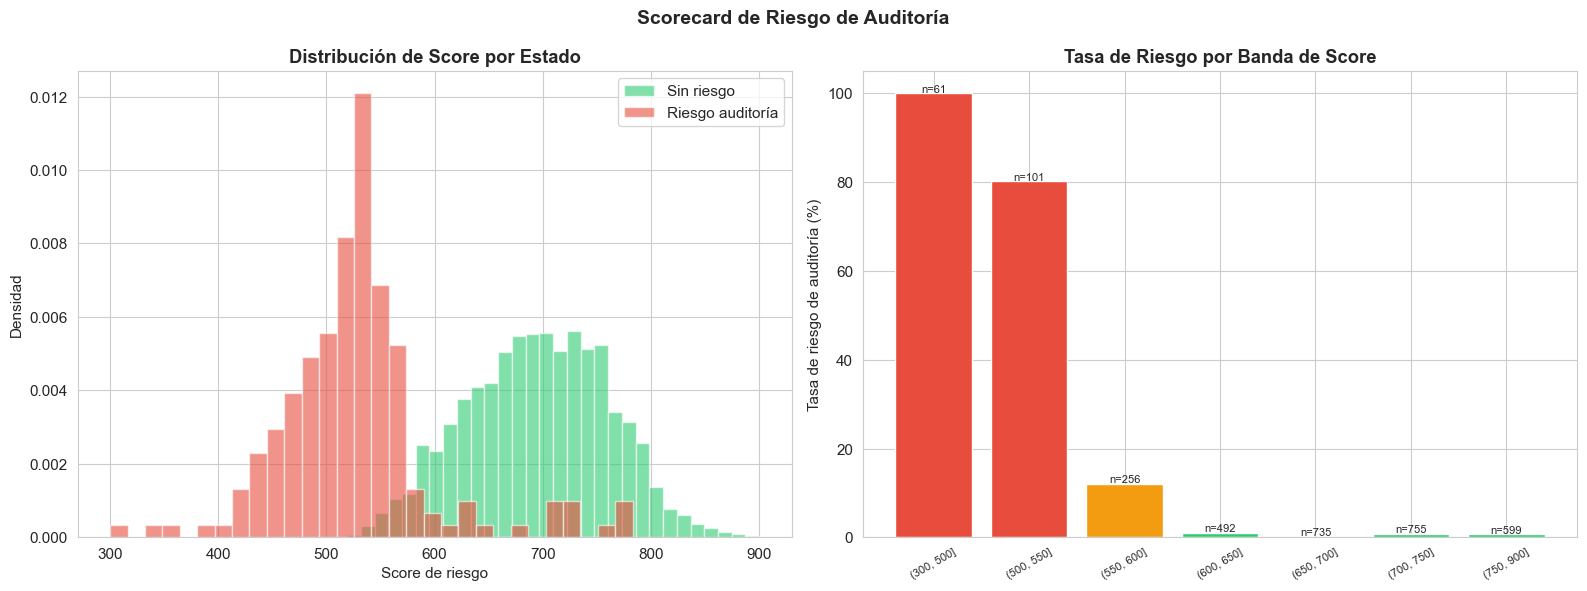


CLASIFICACIÓN DE RIESGO POR SCORE:
Score < 550: Riesgo MUY ALTO (revisión prioritaria)
Score 550-600: Riesgo ALTO (revisión manual)
Score 600-650: Riesgo MEDIO (seguimiento)
Score 650-700: Riesgo BAJO
Score > 700: Riesgo MUY BAJO


In [27]:
def prob_to_score(prob, pdo=20, odds=1, factor=None, offset=None):
    """
    Convierte probabilidad estimada en un score de riesgo.
    PDO (Points to Double Odds): puntos para duplicar odds.
    """
    if factor is None:
        factor = pdo / np.log(2)
    if offset is None:
        offset = 600 - factor * np.log(odds)

    score = offset - factor * np.log(prob / (1 - prob + 1e-10))
    return np.clip(score, 300, 900).astype(int)

# Calcular scores
scores_test = prob_to_score(y_prob)

# Distribución de scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(scores_test[y_test==0], bins=30, alpha=0.6, color='#2ecc71', label='Sin riesgo', density=True)
axes[0].hist(scores_test[y_test==1], bins=30, alpha=0.6, color='#e74c3c', label='Riesgo auditoría', density=True)
axes[0].set_xlabel('Score de riesgo')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Score por Estado', fontweight='bold')
axes[0].legend()

# Tasa de riesgo por banda de score
bandas_score = pd.cut(scores_test, bins=[300, 500, 550, 600, 650, 700, 750, 900])
tasa_por_banda = pd.DataFrame({'banda': bandas_score, 'riesgo': y_test.values}).groupby('banda')['riesgo'].agg(['mean', 'count'])
tasa_por_banda.columns = ['tasa_riesgo', 'n']

axes[1].bar(range(len(tasa_por_banda)), tasa_por_banda['tasa_riesgo']*100,
            color=['#e74c3c' if x > 0.15 else '#f39c12' if x > 0.08 else '#2ecc71' 
                   for x in tasa_por_banda['tasa_riesgo']])
axes[1].set_xticks(range(len(tasa_por_banda)))
axes[1].set_xticklabels([str(b) for b in tasa_por_banda.index], rotation=30, fontsize=8)
axes[1].set_ylabel('Tasa de riesgo de auditoría (%)')
axes[1].set_title('Tasa de Riesgo por Banda de Score', fontweight='bold')
for i, (tasa, n) in enumerate(zip(tasa_por_banda['tasa_riesgo'], tasa_por_banda['n'])):
    axes[1].text(i, tasa*100 + 0.2, f'n={n}', ha='center', fontsize=8)

plt.suptitle('Scorecard de Riesgo de Auditoría', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCLASIFICACIÓN DE RIESGO POR SCORE:")
print("Score < 550: Riesgo MUY ALTO (revisión prioritaria)")
print("Score 550-600: Riesgo ALTO (revisión manual)")
print("Score 600-650: Riesgo MEDIO (seguimiento)")
print("Score 650-700: Riesgo BAJO")
print("Score > 700: Riesgo MUY BAJO")


---
# 🎯 EJERCICIOS PRÁCTICOS PARA AUDITORES

**Instrucciones:** Resuelve los siguientes ejercicios usando los conceptos aprendidos. Cada ejercicio viene con datos nuevos que debes analizar y modelar desde cero.

---

### 📝 EJERCICIO 1: Detección de Fraude en Transacciones

**Contexto:** El departamento de fraude del banco te proporciona datos de transacciones con tarjeta de crédito. Tu tarea es construir un modelo de regresión logística para detectar fraudes.

**Tareas:**
1. Realiza el EDA completo del dataset
2. Analiza el desbalanceo de clases y aplica la técnica adecuada
3. Construye y evalúa el modelo
4. Calcula AUC, KS y Gini
5. Determina el umbral óptimo considerando que: detectar un fraude vale 500€ y una falsa alarma cuesta 50€

In [ ]:
# === DATOS EJERCICIO 1: Fraude en Transacciones ===
np.random.seed(101)
n_trans = 10000

df_fraude = pd.DataFrame({
    'id_transaccion': range(1, n_trans+1),
    'importe': np.random.lognormal(4.5, 1.2, n_trans).clip(1, 50000),
    'hora_dia': np.random.randint(0, 24, n_trans),
    'tipo_comercio': np.random.choice(['Online', 'Presencial', 'Cajero', 'Internacional'], n_trans, p=[0.30, 0.45, 0.15, 0.10]),
    'distancia_habitual_km': np.random.exponential(50, n_trans).clip(0, 5000),
    'num_transacciones_1h': np.random.poisson(1.5, n_trans).clip(0, 20),
    'dias_desde_ultima_trans': np.random.exponential(2, n_trans).clip(0, 30),
    'num_declinos_30d': np.random.choice([0, 1, 2, 3, 4, 5], n_trans, p=[0.75, 0.12, 0.07, 0.03, 0.02, 0.01]),
    'es_pais_riesgo': np.random.choice([0, 1], n_trans, p=[0.85, 0.15]),
    'velocidad_transacciones': np.random.exponential(0.5, n_trans).clip(0, 10),
    'importe_desviacion_perfil': np.random.exponential(1.0, n_trans).clip(0, 20),
    'es_primera_compra_comercio': np.random.choice([0, 1], n_trans, p=[0.60, 0.40]),
})

# Variable objetivo: Fraude (muy desbalanceado - realista)
log_odds_fraude = (
    -5.5
    + 0.3 * (df_fraude['hora_dia'] < 6).astype(int)
    + 0.001 * df_fraude['importe']
    + 0.01 * df_fraude['distancia_habitual_km']
    + 0.3 * df_fraude['num_transacciones_1h']
    + 0.5 * df_fraude['num_declinos_30d']
    + 1.5 * df_fraude['es_pais_riesgo']
    + 0.8 * df_fraude['velocidad_transacciones']
    + 0.5 * df_fraude['importe_desviacion_perfil']
    + 0.4 * df_fraude['es_primera_compra_comercio']
)
prob_fraude = 1 / (1 + np.exp(-log_odds_fraude))
df_fraude['fraude'] = (np.random.uniform(0, 1, n_trans) < prob_fraude).astype(int)

print("DATASET FRAUDE:")
print(f"Total transacciones: {len(df_fraude):,}")
print(f"Fraudes: {df_fraude['fraude'].sum():,} ({df_fraude['fraude'].mean()*100:.2f}%)")
print("\nPrimeras filas:")
df_fraude.head()

In [ ]:
# TU SOLUCIÓN AQUÍ - EJERCICIO 1
# Paso 1: EDA del dataset de fraude

# =====================
# ESCRIBE TU CÓDIGO AQUÍ
# =====================
raise NotImplementedError("⚠️ Completa este ejercicio")

### 📝 EJERCICIO 2: Modelo de Mora Temprana (Early Default)

**Contexto:** El banco quiere identificar clientes con alto riesgo de entrar en mora durante los primeros 3 meses del crédito.

**Tareas:**
1. Analiza las variables disponibles e identifica las más predictoras
2. Aplica la regularización L1 (Lasso) y compara con L2 (Ridge)
3. Evalúa si existe multicolinealidad entre las variables
4. Construye un modelo parsimonioso (pocas variables pero efectivo)
5. Interpreta los coeficientes en términos de negocio bancario

In [ ]:
# DATOS EJERCICIO 2: Mora temprana
np.random.seed(202)
n_creditos = 3000

df_mora = pd.DataFrame({
    'id_credito': range(1, n_creditos+1),
    'score_al_originar': np.random.normal(640, 80, n_creditos).clip(300, 850).astype(int),
    'edad': np.random.normal(38, 10, n_creditos).clip(20, 70).astype(int),
    'ingresos_mensual': np.random.normal(2000, 600, n_creditos).clip(600, 6000),
    'cuota_mensual': np.random.normal(350, 150, n_creditos).clip(100, 2000),
    'importe_credito': np.random.normal(15000, 8000, n_creditos).clip(2000, 80000),
    'num_cuentas_abiertas': np.random.poisson(3, n_creditos).clip(0, 10),
    'utilizacion_tarjeta_pct': np.random.uniform(0, 1, n_creditos),
    'anos_historial_credito': np.random.exponential(5, n_creditos).clip(0, 30),
    'num_consultas_credito_6m': np.random.poisson(1.5, n_creditos).clip(0, 10),
    'tiene_hipoteca': np.random.choice([0,1], n_creditos, p=[0.60, 0.40]),
    'num_hijos': np.random.choice([0,1,2,3,4], n_creditos, p=[0.30, 0.25, 0.28, 0.12, 0.05]),
    'estado_civil': np.random.choice(['Soltero','Casado','Divorciado'], n_creditos, p=[0.40, 0.45, 0.15]),
    'zona_geografica': np.random.choice(['Norte','Centro','Sur','Este','Oeste'], n_creditos)
})

ratio_cuota_ingreso = df_mora['cuota_mensual'] / df_mora['ingresos_mensual']
log_odds_mora = (
    -4.0
    - 0.004 * (df_mora['score_al_originar'] - 500)
    + 1.5 * ratio_cuota_ingreso
    + 0.8 * df_mora['utilizacion_tarjeta_pct']
    + 0.3 * df_mora['num_consultas_credito_6m']
    - 0.05 * df_mora['anos_historial_credito']
    + 0.1 * df_mora['num_hijos']
)
prob_mora = 1 / (1 + np.exp(-log_odds_mora))
df_mora['mora_90d'] = (np.random.uniform(0, 1, n_creditos) < prob_mora).astype(int)

print(f"Dataset mora temprana: {len(df_mora):,} créditos, {df_mora['mora_90d'].mean()*100:.1f}% en mora")
df_mora.head()

In [ ]:
# TU SOLUCIÓN AQUÍ - EJERCICIO 2
# =====================
# ESCRIBE TU CÓDIGO AQUÍ
# =====================
raise NotImplementedError("⚠️ Completa este ejercicio")

### 📝 EJERCICIO 3: Análisis de Estabilidad del Modelo en el Tiempo

**Contexto:** El banco tiene un modelo de crédito que lleva 12 meses en producción. Debes auditar si el modelo sigue siendo válido o necesita ser reentrenado.

**Tareas:**
1. Calcula el PSI para comparar la población original vs 12 meses después
2. Compara el AUC y KS entre ambos períodos
3. Analiza la deriva (drift) en las variables más importantes
4. Genera un informe de auditoría del modelo con conclusiones
5. Recomienda si el modelo debe reentrenarse o si puede seguir en producción

In [ ]:
# DATOS EJERCICIO 3: Monitoreo temporal del modelo
# Usa el modelo ya entrenado (modelo_lr, scaler, X) y simula deriva temporal

np.random.seed(303)

# Población original (mes 0)
df_mes0 = df.sample(n=2000, replace=True, random_state=1).copy()

# Población 12 meses después con deriva operativa
df_mes12 = df.sample(n=2000, replace=True, random_state=2).copy()

# Simular deterioro del entorno de auditoría:
# más importe, más alertas, más operaciones internacionales y menor score
df_mes12['importe_operacion'] *= np.random.normal(1.15, 0.10, len(df_mes12)).clip(0.90, 1.50)
df_mes12['importe_total_30d'] *= np.random.normal(1.12, 0.12, len(df_mes12)).clip(0.85, 1.60)
df_mes12['num_alertas_previas'] = (df_mes12['num_alertas_previas'] + np.random.binomial(1, 0.20, len(df_mes12))).clip(0)
df_mes12['score_crediticio'] -= np.random.normal(25, 10, len(df_mes12))
df_mes12['score_crediticio'] = df_mes12['score_crediticio'].clip(300, 900)
df_mes12['porcentaje_operaciones_internacionales'] = (
    df_mes12['porcentaje_operaciones_internacionales'] + np.random.normal(0.05, 0.03, len(df_mes12))
).clip(0, 1)

print("COMPARACIÓN DE POBLACIONES:")
print(f"Mes 0  - Importe medio: {df_mes0['importe_operacion'].mean():.0f}€ | Score medio: {df_mes0['score_crediticio'].mean():.0f} | Alertas medias: {df_mes0['num_alertas_previas'].mean():.2f}")
print(f"Mes 12 - Importe medio: {df_mes12['importe_operacion'].mean():.0f}€ | Score medio: {df_mes12['score_crediticio'].mean():.0f} | Alertas medias: {df_mes12['num_alertas_previas'].mean():.2f}")
print("\n¿Ha habido deriva en la población? Analízalo en tu solución.")


In [ ]:
# TU SOLUCIÓN AQUÍ - EJERCICIO 3
# =====================
# ESCRIBE TU CÓDIGO AQUÍ
# =====================
raise NotImplementedError("⚠️ Completa este ejercicio")

### 📝 EJERCICIO 4: Modelo de Sospecha de Blanqueo de Capitales

**Contexto:** El departamento de Cumplimiento necesita un modelo para priorizar las operaciones a revisar por posible blanqueo de capitales (AML - Anti Money Laundering).

**Tareas:**
1. Construye un modelo de regresión logística para detectar operaciones sospechosas
2. Evalúa el trade-off entre falsas alarmas y detecciones perdidas
3. Genera una lista de priorización de casos para el equipo de cumplimiento
4. Calcula cuántas operaciones debería revisar el equipo para capturar el 80% de las sospechosas
5. Exporta los 50 casos de mayor riesgo con explicación del modelo

In [ ]:
# DATOS EJERCICIO 4: AML - Blanqueo de capitales
np.random.seed(404)
n_ops = 8000

df_aml = pd.DataFrame({
    'id_operacion': range(1, n_ops+1),
    'importe': np.random.lognormal(8, 1.5, n_ops).clip(500, 1000000),
    'num_operaciones_mismo_dia': np.random.poisson(2, n_ops).clip(1, 50),
    'pais_origen': np.random.choice(['España','Alemania','UK','Rusia','Panama','Islas_Cayman','UAE','USA'], 
                                     n_ops, p=[0.40, 0.15, 0.15, 0.08, 0.07, 0.05, 0.05, 0.05]),
    'tipo_cuenta': np.random.choice(['Corriente','Ahorro','Empresarial','Offshore'], n_ops, p=[0.50, 0.25, 0.20, 0.05]),
    'edad_cuenta_meses': np.random.exponential(24, n_ops).clip(1, 240).astype(int),
    'num_titulares': np.random.choice([1,2,3,4,5], n_ops, p=[0.60, 0.25, 0.10, 0.03, 0.02]),
    'operaciones_redondas_30d': np.random.poisson(0.5, n_ops).clip(0, 20),
    'variacion_vs_media_pct': np.random.exponential(0.3, n_ops).clip(0, 10),
    'hora_operacion': np.random.randint(0, 24, n_ops),
    'sector_economico': np.random.choice(['Inmobiliario','Hostelería','Joyería','Transporte','Financiero','Retail'], 
                                          n_ops, p=[0.20, 0.15, 0.10, 0.15, 0.20, 0.20]),
    'fraccionamiento_indicios': np.random.choice([0,1], n_ops, p=[0.85, 0.15]),
})

paises_riesgo = ['Rusia', 'Panama', 'Islas_Cayman', 'UAE']
df_aml['pais_riesgo'] = df_aml['pais_origen'].isin(paises_riesgo).astype(int)
sectores_riesgo = ['Inmobiliario', 'Hostelería', 'Joyería']
df_aml['sector_riesgo'] = df_aml['sector_economico'].isin(sectores_riesgo).astype(int)

log_odds_aml = (
    -6.0
    + 0.0000008 * df_aml['importe']
    + 0.1 * df_aml['num_operaciones_mismo_dia']
    + 2.0 * df_aml['pais_riesgo']
    + 0.8 * df_aml['sector_riesgo']
    - 0.01 * df_aml['edad_cuenta_meses']
    + 0.5 * df_aml['operaciones_redondas_30d']
    + 1.5 * df_aml['variacion_vs_media_pct']
    + 1.8 * df_aml['fraccionamiento_indicios']
    + 0.5 * (df_aml['hora_operacion'] < 7).astype(int)
    + 0.5 * (df_aml['tipo_cuenta'] == 'Offshore').astype(int)
)
prob_aml = 1 / (1 + np.exp(-log_odds_aml))
df_aml['sospechoso'] = (np.random.uniform(0, 1, n_ops) < prob_aml).astype(int)

print(f"Dataset AML: {len(df_aml):,} operaciones")
print(f"Sospechosas: {df_aml['sospechoso'].sum():,} ({df_aml['sospechoso'].mean()*100:.1f}%)")
df_aml.head()

In [ ]:
# TU SOLUCIÓN AQUÍ - EJERCICIO 4
# =====================
# ESCRIBE TU CÓDIGO AQUÍ
# =====================
raise NotImplementedError("⚠️ Completa este ejercicio")

### 📝 EJERCICIO 5: Segmentación de Crédito por Perfil de Riesgo

**Contexto:** El banco usa actualmente un único umbral de 0.5 para aprobar/denegar créditos. Tu tarea es desarrollar un sistema de tres segmentos de riesgo (Verde/Amarillo/Rojo) con diferentes condiciones.

**Tareas:**
1. Entrena un modelo de regresión logística con regularización óptima (tuning de C)
2. Define umbrales para tres segmentos: Bajo (Verde), Medio (Amarillo), Alto (Rojo)
3. Para cada segmento, calcula: tasa de default, tamaño del segmento, importe medio aprobado
4. Diseña una política de crédito diferenciada (tipos de interés, plazos, garantías) por segmento
5. Estima el impacto económico (pérdida esperada) de tu política vs la política actual

In [ ]:
# Usa el dataset principal df ya cargado y el modelo entrenado para este ejercicio
# Pero añade nuevas variables de negocio

np.random.seed(505)
df_segmentacion = df.copy()
df_segmentacion['tasa_interes_ofrecida'] = np.random.uniform(4.5, 18.5, len(df))
df_segmentacion['lgd_estimada'] = np.random.uniform(0.35, 0.65, len(df))  # Loss Given Default

# En el nuevo dataset, el equivalente de exposición operativa será el importe de la operación
df_segmentacion['ead'] = df_segmentacion['importe_operacion'] * np.random.uniform(0.7, 1.0, len(df))

print("Variables adicionales para ejercicio de segmentación:")
print("- tasa_interes_ofrecida")
print("- lgd_estimada")
print("- ead")
display(df_segmentacion.head())


In [ ]:
# TU SOLUCIÓN AQUÍ - EJERCICIO 5
# =====================
# ESCRIBE TU CÓDIGO AQUÍ
# =====================
raise NotImplementedError("⚠️ Completa este ejercicio")

### 📝 EJERCICIO 6: Modelo de Churn Bancario

**Contexto:** El banco quiere identificar clientes con alto riesgo de cerrar sus cuentas en los próximos 3 meses.

**Tareas:**
1. EDA completo con enfoque en patrones de comportamiento antes del abandono
2. Construye el modelo con al menos 3 variantes (diferentes hiperparámetros)
3. Selecciona el mejor modelo usando validación cruzada
4. Implementa el modelo en una función de scoring para nuevos clientes
5. Genera recomendaciones de retención para los 200 clientes con mayor riesgo

In [ ]:
# DATOS EJERCICIO 6: Churn bancario
np.random.seed(606)
n_clientes_churn = 6000

df_churn = pd.DataFrame({
    'id_cliente': range(1, n_clientes_churn+1),
    'antiguedad_anos': np.random.exponential(5, n_clientes_churn).clip(0.1, 30),
    'num_productos': np.random.poisson(2, n_clientes_churn).clip(1, 8),
    'saldo_medio_6m': np.random.lognormal(7.5, 1.2, n_clientes_churn).clip(0, 100000),
    'variacion_saldo_3m_pct': np.random.normal(-0.05, 0.3, n_clientes_churn),
    'transacciones_mes_actual': np.random.poisson(15, n_clientes_churn).clip(0, 100),
    'variacion_transacciones_pct': np.random.normal(-0.1, 0.4, n_clientes_churn),
    'dias_ultimo_acceso_app': np.random.exponential(15, n_clientes_churn).clip(0, 180).astype(int),
    'num_quejas_12m': np.random.choice([0,1,2,3,4,5], n_clientes_churn, p=[0.60,0.20,0.10,0.05,0.03,0.02]),
    'nps_score': np.random.choice(range(-100, 101, 10), n_clientes_churn),
    'tiene_hipoteca': np.random.choice([0,1], n_clientes_churn, p=[0.55, 0.45]),
    'tiene_seguro': np.random.choice([0,1], n_clientes_churn, p=[0.50, 0.50]),
    'tiene_plan_pension': np.random.choice([0,1], n_clientes_churn, p=[0.65, 0.35]),
    'canal_principal': np.random.choice(['App','Web','Oficina','Telefono'], n_clientes_churn, p=[0.40,0.30,0.20,0.10]),
    'segmento': np.random.choice(['Mass','Mass Affluent','Affluent','Private'], n_clientes_churn, p=[0.55,0.25,0.15,0.05]),
})

log_odds_churn = (
    -2.5
    - 0.1 * df_churn['antiguedad_anos']
    - 0.3 * df_churn['num_productos']
    - 0.000003 * df_churn['saldo_medio_6m']
    - 1.5 * df_churn['variacion_saldo_3m_pct']
    + 0.03 * df_churn['dias_ultimo_acceso_app']
    + 0.5 * df_churn['num_quejas_12m']
    - 0.01 * df_churn['nps_score']
    - 0.8 * df_churn['tiene_hipoteca']
    - 0.5 * df_churn['tiene_seguro']
    - 0.7 * df_churn['tiene_plan_pension']
    - 1.2 * (df_churn['variacion_transacciones_pct'] > 0).astype(int)
)
prob_churn = 1 / (1 + np.exp(-log_odds_churn))
df_churn['churn'] = (np.random.uniform(0, 1, n_clientes_churn) < prob_churn).astype(int)

print(f"Dataset Churn: {len(df_churn):,} clientes")
print(f"Tasa de abandono: {df_churn['churn'].mean()*100:.1f}%")
df_churn.head()

In [ ]:
# TU SOLUCIÓN AQUÍ - EJERCICIO 6
# =====================
# ESCRIBE TU CÓDIGO AQUÍ
# =====================
raise NotImplementedError("⚠️ Completa este ejercicio")

### 📝 EJERCICIO 7: Validación de Modelo Externo (Auditoría de Terceros)

**Contexto:** El banco ha contratado un modelo de scoring a una empresa externa. Tu tarea como auditor es validar que el modelo cumple los estándares regulatorios (Basilea III).

**Tareas:**
1. Verifica la discriminación del modelo (AUC, KS, Gini) en el portafolio del banco
2. Analiza si el modelo tiene sesgos por género, edad o zona geográfica
3. Verifica la calibración: ¿Las probabilidades predichas corresponden a tasas reales?
4. Compara el modelo externo con uno que construyas tú mismo
5. Emite un dictamen de auditoría con semáforo: ✅ Aprobado / ⚠️ Condicionado / ❌ Rechazado

In [ ]:
# DATOS EJERCICIO 7: Modelo externo para validar
np.random.seed(707)
n_val = 4000

df_validacion = df.sample(n=n_val, replace=True, random_state=77).copy()
df_validacion['genero'] = np.random.choice(['M', 'F'], n_val, p=[0.52, 0.48])
df_validacion['zona'] = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'], n_val)

# Simular scores del modelo externo (con cierto sesgo en algunos segmentos)
score_ext = 700 - 0.3 * (700 - df_validacion['score_crediticio'])  # Modelo menos discriminante

# Introducir sesgo artificial por género
score_ext = np.where(df_validacion['genero'] == 'F', score_ext - 20, score_ext)  # Sesgo de -20 puntos para mujeres
score_ext += np.random.normal(0, 15, n_val)

df_validacion['score_modelo_externo'] = score_ext.clip(300, 850).astype(int)
df_validacion['prob_modelo_externo'] = 1 / (1 + np.exp((df_validacion['score_modelo_externo'] - 600) / 50))

print("DATASET PARA VALIDACIÓN DE MODELO EXTERNO:")
print(f"Operaciones: {len(df_validacion):,}")
print(f"Tasa riesgo auditoría: {df_validacion[TARGET].mean()*100:.1f}%")
print(f"Score externo medio: {df_validacion['score_modelo_externo'].mean():.0f}")
print(f"\nATENCIÓN: ¿Hay sesgo por género? Mujeres: {df_validacion[df_validacion['genero']=='F']['score_modelo_externo'].mean():.0f} | Hombres: {df_validacion[df_validacion['genero']=='M']['score_modelo_externo'].mean():.0f}")

df_validacion[[ID_COL, 'genero', 'zona', 'score_crediticio', 'score_modelo_externo', 'prob_modelo_externo', TARGET]].head()


In [ ]:
# TU SOLUCIÓN AQUÍ - EJERCICIO 7
# =====================
# ESCRIBE TU CÓDIGO AQUÍ
# =====================
raise NotImplementedError("⚠️ Completa este ejercicio")

### 📝 EJERCICIO 8: Modelo de Aprobación de Tarjetas de Crédito

**Contexto:** El banco quiere automatizar la aprobación de tarjetas de crédito con límites diferenciados.

**Tareas:**
1. Construye un modelo binario de aprobación (Sí/No)
2. Para los aprobados, calcula el límite recomendado basado en la probabilidad de default
3. Analiza si el modelo cumple la regulación GDPR (no usa datos protegidos directamente)
4. Implementa un sistema de revisión manual para casos en zona gris (0.4-0.6 de probabilidad)
5. Estima el revenue anual del portafolio de tarjetas con tu política de aprobación

In [ ]:
# DATOS EJERCICIO 8: Aprobación de tarjetas
np.random.seed(808)
n_solicitudes = 7000

df_tarjetas = pd.DataFrame({
    'id_solicitud': range(1, n_solicitudes+1),
    'ingresos_anuales': np.random.lognormal(10, 0.6, n_solicitudes).clip(15000, 300000),
    'score_buro': np.random.normal(640, 90, n_solicitudes).clip(300, 850).astype(int),
    'anos_empleo': np.random.exponential(5, n_solicitudes).clip(0, 35),
    'ratio_utilizacion_actual': np.random.uniform(0, 1, n_solicitudes),
    'num_cuentas_corrientes': np.random.poisson(1.5, n_solicitudes).clip(0, 5),
    'deuda_total': np.random.lognormal(8.5, 1.0, n_solicitudes).clip(0, 200000),
    'num_impagos_2anos': np.random.choice([0,1,2,3], n_solicitudes, p=[0.72, 0.17, 0.07, 0.04]),
    'tiene_cuenta_banco': np.random.choice([0,1], n_solicitudes, p=[0.35, 0.65]),
    'anos_historial_crediticio': np.random.exponential(7, n_solicitudes).clip(0, 40),
    'limite_solicitado': np.random.choice([500, 1000, 2000, 3000, 5000, 8000, 10000], n_solicitudes),
})

log_odds_tarjeta = (
    -4.0
    - 0.000004 * df_tarjetas['ingresos_anuales']
    - 0.003 * (df_tarjetas['score_buro'] - 500)
    - 0.05 * df_tarjetas['anos_empleo']
    + 1.2 * df_tarjetas['ratio_utilizacion_actual']
    + 0.000003 * df_tarjetas['deuda_total']
    + 0.7 * df_tarjetas['num_impagos_2anos']
    - 0.4 * df_tarjetas['tiene_cuenta_banco']
    - 0.02 * df_tarjetas['anos_historial_crediticio']
)
prob_impago = 1 / (1 + np.exp(-log_odds_tarjeta))
df_tarjetas['impago_12m'] = (np.random.uniform(0, 1, n_solicitudes) < prob_impago).astype(int)

print(f"Dataset Tarjetas: {len(df_tarjetas):,} solicitudes")
print(f"Tasa de impago: {df_tarjetas['impago_12m'].mean()*100:.1f}%")
df_tarjetas.head()

In [ ]:
# TU SOLUCIÓN AQUÍ - EJERCICIO 8
# =====================
# ESCRIBE TU CÓDIGO AQUÍ
# =====================
raise NotImplementedError("⚠️ Completa este ejercicio")

### 📝 EJERCICIO 9: Modelo Multivariante con Interacciones

**Contexto:** El analista de riesgos sospecha que hay interacciones importantes entre variables (ej: el efecto de los ingresos depende del tipo de contrato).

**Tareas:**
1. Construye un modelo base sin interacciones
2. Identifica las interacciones más relevantes mediante análisis gráfico y estadístico
3. Agrega las interacciones significativas al modelo
4. Compara el modelo con y sin interacciones (AIC, BIC, AUC)
5. Interpreta las interacciones en términos de riesgo bancario y genera documentación

In [ ]:
# DATOS EJERCICIO 9: Analiza interacciones en el dataset principal
# Usa df ya cargado pero añade términos de interacción manualmente

df_interacciones = df.copy()

# Posibles interacciones a investigar con el nuevo dataset:
df_interacciones['importe_x_alertas'] = df_interacciones['importe_operacion'] * df_interacciones['num_alertas_previas']
df_interacciones['score_x_deuda'] = df_interacciones['score_crediticio'] * df_interacciones['ratio_ingresos_deuda']
df_interacciones['internacional_x_pais_riesgo'] = df_interacciones['porcentaje_operaciones_internacionales'] * (
    df_interacciones['pais_riesgo'].map({'bajo': 1, 'medio': 2, 'alto': 3}).fillna(1)
)
df_interacciones['importe30d_x_operaciones30d'] = df_interacciones['importe_total_30d'] * df_interacciones['num_operaciones_30d']

print("Dataset con interacciones:")
print(df_interacciones[['importe_x_alertas', 'score_x_deuda', 'internacional_x_pais_riesgo', 
                        'importe30d_x_operaciones30d', TARGET]].head())


In [ ]:
# TU SOLUCIÓN AQUÍ - EJERCICIO 9
# =====================
# ESCRIBE TU CÓDIGO AQUÍ
# =====================
raise NotImplementedError("⚠️ Completa este ejercicio")

### 📝 EJERCICIO 10: Informe Integral de Auditoría del Modelo

**Contexto:** Debes preparar un informe completo de auditoría del modelo de regresión logística para presentarlo al Comité de Riesgos del banco.

**Tareas (producir todas las secciones del informe):**
1. **Sección 1 - Descripción del modelo:** Arquitectura, variables, metodología
2. **Sección 2 - Calidad de datos:** Análisis de completitud, consistencia y distribuciones
3. **Sección 3 - Rendimiento:** AUC, KS, Gini, Calibración, Brier Score
4. **Sección 4 - Estabilidad:** PSI, análisis temporal, deriva de variables
5. **Sección 5 - Equidad (Fairness):** Análisis de sesgos por grupos protegidos
6. **Sección 6 - Conclusiones y semáforo de riesgos:** ✅ / ⚠️ / 🔴 para cada sección
7. **Sección 7 - Recomendaciones:** Plan de acción con prioridades y responsables

**Genera un dashboard visual completo con todos los indicadores.**

In [ ]:
# DATOS EJERCICIO 10: Usa todos los datasets anteriores
# El informe debe consolidar los análisis de todos los ejercicios anteriores

print("="*60)
print("EJERCICIO INTEGRADOR: INFORME DE AUDITORÍA DE MODELO")
print("="*60)
print()
print("Datasets disponibles:")
print(f"  - df: Dataset principal de auditoría bancaria ({len(df):,} operaciones)")
print(f"  - df_fraude: Transacciones de fraude ({len(df_fraude):,} transacciones)")
print(f"  - df_mora: Mora temprana ({len(df_mora):,} créditos)")
print(f"  - df_aml: AML - Blanqueo de capitales ({len(df_aml):,} operaciones)")
print(f"  - df_churn: Churn bancario ({len(df_churn):,} clientes)")
print(f"  - df_tarjetas: Aprobación de tarjetas ({len(df_tarjetas):,} solicitudes)")
print()
print("Objetivo:")
print("Redactar un informe ejecutivo de validación del modelo de regresión logística adaptado al dataset nuevo.")
print()
print("Debe incluir:")
print("1. Calidad y estructura del dataset")
print("2. Desbalanceo de clases")
print("3. Variables relevantes")
print("4. Rendimiento del modelo")
print("5. Interpretación de coeficientes y odds ratios")
print("6. Estabilidad poblacional mediante PSI")
print("7. Recomendaciones de uso en auditoría bancaria")


In [ ]:
# TU SOLUCIÓN AQUÍ - EJERCICIO 10 (INTEGRADOR)
# =====================
# ESCRIBE TU CÓDIGO AQUÍ
# =====================
raise NotImplementedError("⚠️ Completa este ejercicio integrador")

---
## 📚 RECURSOS ADICIONALES

### Regulación y Estándares
- **Basilea III/IV:** Marco regulatorio para modelos de crédito en bancos
- **EBA Guidelines on Internal Governance (2021):** Requisitos de gobernanza de modelos
- **SR 11-7:** Directrices de la Fed sobre gestión del riesgo de modelos
- **ECB Guide to Internal Models (TRIM):** Validación de modelos internos

### Métricas Clave para Recordar

| Métrica | Fórmula | Umbral Bancario |
|---------|---------|----------------|
| AUC | Área bajo curva ROC | > 0.75 |
| Gini | 2×AUC - 1 | > 0.50 |
| KS | max(TPR - FPR) | > 0.40 |
| PSI | Σ(Act%-Exp%)×ln(Act%/Exp%) | < 0.10 |
| Brier | E[(p-y)²] | < 0.10 |

### Checklist de Auditoría de Modelos
- [ ] Documentación completa del modelo
- [ ] Calidad de datos verificada
- [ ] Discriminación en umbral aceptable
- [ ] Calibración verificada
- [ ] Estabilidad temporal confirmada (PSI < 0.10)
- [ ] Sin sesgos por grupos protegidos
- [ ] Aprobado por comité de modelos
- [ ] Plan de monitoreo establecido
---
*Notebook desarrollado para el programa de formación en analítica avanzada para auditores bancarios*